**Introdução**

*O que é Análise Exploratória de Dados (EDA)?*

Análise Exploratória de Dados, ou EDA, é o processo de entender conjuntos de dados resumindo suas principais características, frequentemente utilizando visualizações. Essa etapa é crucial, especialmente ao modelar os dados para aplicar aprendizado de máquina. A EDA inclui gráficos como histogramas, box plots, scatter plots e outros.

*Como realizar a Análise Exploratória de Dados?*

A resposta depende do conjunto de dados em questão. Não existe um método único para realizar a EDA. Neste tutorial, vamos empregar alguns dos pricipais métodos e gráficos comuns utilizados no processo de EDA.

*Quais dados vamos utilizar?*

Iremos adotar dados do portal de transparência do Estado de São Paulo, remuneração mensal de servidores públicos ativos.

Referências:
https://www.kaggle.com/code/imoore/intro-to-exploratory-data-analysis-eda-in-python

https://medium.com/@ugursavci/complete-exploratory-data-analysis-using-python-9f685d67d1e4

https://www.kaggle.com/code/ekami66/detailed-exploratory-data-analysis-with-python

https://www.analyticsvidhya.com/blog/2022/07/step-by-step-exploratory-data-analysis-eda-using-python/

Dataset: https://www.transparencia.sp.gov.br/home/Remuneracao

**Importando as bibliotecas**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns                       #visualisation
import matplotlib.pyplot as plt             #visualisation
%matplotlib inline
sns.set(color_codes=True)

# **Etapa 1- Carregando os dados**

**Carregando os dados**

In [ ]:
#Subindo dados para o colab
from google.colab import files
uploaded_files = files.upload()

Saving Remuneracao.txt to Remuneracao.txt


**Salvando os dados em um dataframe**

In [ ]:
df = pd.read_csv('Remuneracao.txt', encoding='latin-1', sep=';')    # Novembro 2025

**Ok, e agora o que vamos fazer com isso?**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1039706 entries, 0 to 1039705
Data columns (total 11 columns):
 #   Column                                   Non-Null Count    Dtype 
---  ------                                   --------------    ----- 
 0   NOME                                     1039706 non-null  object
 1   CARGO                                    1039647 non-null  object
 2   ORGÃO                                    1039706 non-null  object
 3   REMUNERAÇÃO DO MÊS                       1039706 non-null  object
 4   FÉRIAS E 13º SALÁRIO                     1039706 non-null  object
 5   PAGAMENTOS EVENTUAIS                     1039706 non-null  object
 6   LICENÇA PRÊMIO INDENIZADA                1039706 non-null  object
 7   ABONO PERMANÊNCIA & OUTRAS INDENIZAÇÕES  1039706 non-null  object
 8   REDUTOR SALARIAL                         1039706 non-null  object
 9   TOTAL LIQUÍDO (R$)                       1039706 non-null  object
 10  GRUPO                         

Veja o problema, as variáveis numéricas estão como objeto!

**Vamos ver o dataset agora:**

In [ ]:
df.head() #visualizando cabeçalho do dataset

,NOME,CARGO,ORGÃO,REMUNERAÇÃO DO MÊS,FÉRIAS E 13º SALÁRIO,PAGAMENTOS EVENTUAIS,LICENÇA PRÊMIO INDENIZADA,ABONO PERMANÊNCIA & OUTRAS INDENIZAÇÕES,REDUTOR SALARIAL,TOTAL LIQUÍDO (R$),GRUPO
0,A UCENA ROSA REGINALDO SILVA,ESTAGIARIO,FUND.PE.ANCHIETA-C.P.RADIO TV.,"1400,00","0,00","0,00","0,00","0,00","0,00","1400,00",ATIVOS
1,AA HELENA PEREIRA ISOLDI DOS S,AGENTE DE SERVICOS ESCOLARES,SAO PAULO PREVIDENCIA SPPREV,"2512,06","0,00","0,00","0,00","0,00","0,00","1631,91",APOSENTADOS
2,AALAN DA SILVA ARAUJO,SD 1C PM,POLICIA MILITAR SAO PAULO,"5571,16","0,00","0,00","0,00","999,54","0,00","2988,11",ATIVOS
3,AARAN ESTEVAO LIMA BARBOSA,CAP PM,POLICIA MILITAR SAO PAULO,"17445,85","0,00","0,00","0,00","555,30","0,00","7864,12",ATIVOS
4,AARAO HENRIQUE OLIVEIRA,POLICIAL PENAL I,SECRETARIA ADM.PENITENCIARIA,"5481,27","2740,63","0,00","0,00","0,00","0,00","5920,02",ATIVOS


**Conhecendo mais sobre o dataset**

In [ ]:
df.head(10) # Visualizando primeiras 10 linhas

,NOME,CARGO,ORGÃO,REMUNERAÇÃO DO MÊS,FÉRIAS E 13º SALÁRIO,PAGAMENTOS EVENTUAIS,LICENÇA PRÊMIO INDENIZADA,ABONO PERMANÊNCIA & OUTRAS INDENIZAÇÕES,REDUTOR SALARIAL,TOTAL LIQUÍDO (R$),GRUPO
0,A UCENA ROSA REGINALDO SILVA,ESTAGIARIO,FUND.PE.ANCHIETA-C.P.RADIO TV.,"1400,00","0,00","0,00","0,00","0,00","0,00","1400,00",ATIVOS
1,AA HELENA PEREIRA ISOLDI DOS S,AGENTE DE SERVICOS ESCOLARES,SAO PAULO PREVIDENCIA SPPREV,"2512,06","0,00","0,00","0,00","0,00","0,00","1631,91",APOSENTADOS
2,AALAN DA SILVA ARAUJO,SD 1C PM,POLICIA MILITAR SAO PAULO,"5571,16","0,00","0,00","0,00","999,54","0,00","2988,11",ATIVOS
3,AARAN ESTEVAO LIMA BARBOSA,CAP PM,POLICIA MILITAR SAO PAULO,"17445,85","0,00","0,00","0,00","555,30","0,00","7864,12",ATIVOS
4,AARAO HENRIQUE OLIVEIRA,POLICIAL PENAL I,SECRETARIA ADM.PENITENCIARIA,"5481,27","2740,63","0,00","0,00","0,00","0,00","5920,02",ATIVOS
5,AARAO HENRIQUE OLIVEIRA,OUTROS VINCULOS,SECRETARIA ADM.PENITENCIARIA,"296,16","0,00","0,00","0,00","0,00","0,00","270,77",ATIVOS
6,AARIN LEAL SANTOS,PROF ENSINO FUNDAMENTAL/MEDIO,SECRETARIA DA EDUCACAO,"7791,00","1298,49","0,00","0,00","0,00","0,00","7222,92",ATIVOS
7,AARON EMMANUEL PARONETTO CAETA,1TEN PM,POLICIA MILITAR SAO PAULO,"14823,80","0,00","0,00","0,00","666,36","0,00","10807,42",ATIVOS
8,AARON GABRIEL MIRANDA,BENEFICIARIO DE SERVIDOR ESTADUAL-IPESP,SAO PAULO PREVIDENCIA SPPREV,"2510,11","0,00","0,00","0,00","0,00","0,00","2510,11",PENSIONISTAS
9,AARON SALES DE ALMEIDA,CABO PM,POLICIA MILITAR SAO PAULO,"8826,26","24,44","0,00","0,00","888,48","0,00","6421,02",ATIVOS


In [ ]:
df.tail(5)  # Visualizando ultimas cinco colunas

,NOME,CARGO,ORGÃO,REMUNERAÇÃO DO MÊS,FÉRIAS E 13º SALÁRIO,PAGAMENTOS EVENTUAIS,LICENÇA PRÊMIO INDENIZADA,ABONO PERMANÊNCIA & OUTRAS INDENIZAÇÕES,REDUTOR SALARIAL,TOTAL LIQUÍDO (R$),GRUPO
1039701,ZURMA DE SOUZA PINTO,PROF ENSINO FUNDAMENTAL/MEDIO,SECRETARIA DA EDUCACAO,"7930,12","0,00","0,00","0,00","0,00","0,00","4700,73",ATIVOS
1039702,ZUVIA OSPEDAL DA SILVA,BENEFICIARIO DE SERVIDOR ESTADUAL-IPESP,SAO PAULO PREVIDENCIA SPPREV,"1581,26","0,00","0,00","0,00","0,00","0,00","1533,83",PENSIONISTAS
1039703,ZUVIA OSPEDAL DA SILVA,AGENTE DE SERVICOS ESCOLARES,SAO PAULO PREVIDENCIA SPPREV,"1518,00","0,00","0,00","0,00","0,00","0,00","1472,46",APOSENTADOS
1039704,ZUZIMEIRE TOSTES DA SILVA,AGENTE DE SERVICOS ESCOLARES,SAO PAULO PREVIDENCIA SPPREV,"2754,89","0,00","0,00","0,00","0,00","0,00","2604,51",APOSENTADOS
1039705,ZUZU DE OLIVEIRA,BENEFICIARIO DE SERVIDOR ESTADUAL-IPESP,SAO PAULO PREVIDENCIA SPPREV,"3360,66","0,00","0,00","0,00","0,00","0,00","3360,66",PENSIONISTAS


# **Etapa 2 - Limpeza dos dados**

**Acertando nome das colunas**

Nós vamos remover caracteres complexos dos nomes das colunas

In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('(', '')
    .str.replace(')', '')
)

**Vamos verificar nossos dados** - **lembre-se:** *nunca confiar!*

---



In [ ]:
# Verificando dados
print ("Tabela 1 - Verificação de dados")
print(df.info())
print("\n") #paragráfo entre os resultados

# Verificando se há algum valor vazio
print ("Tabela 2 - Verificação de dados vazios")
print(df.isna().any())
print("\n")

# Verificando quantidade de dados vazios
print ("Tabela 3 - Verificação de quantidade de dados vazios")
print(df.isna().sum())
print("\n")

Tabela 1 - Verificação de dados
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1039706 entries, 0 to 1039705
Data columns (total 11 columns):
 #   Column                                   Non-Null Count    Dtype 
---  ------                                   --------------    ----- 
 0   nome                                     1039706 non-null  object
 1   cargo                                    1039647 non-null  object
 2   orgão                                    1039706 non-null  object
 3   remuneração_do_mês                       1039706 non-null  object
 4   férias_e_13º_salário                     1039706 non-null  object
 5   pagamentos_eventuais                     1039706 non-null  object
 6   licença_prêmio_indenizada                1039706 non-null  object
 7   abono_permanência_&_outras_indenizações  1039706 non-null  object
 8   redutor_salarial                         1039706 non-null  object
 9   total_liquído_r$                         1039706 non-null  object
 10

**Os números que observamos estão sendo entendidos como texto, vamos arrumar.**

In [ ]:
# Selecionando as colunas numéricas
colunas_numericas = [
    'remuneração_do_mês',
    'férias_e_13º_salário',
    'pagamentos_eventuais',
    'licença_prêmio_indenizada',
    'abono_permanência_&_outras_indenizações',
    'redutor_salarial',
    'total_liquído_r$'
]

In [ ]:
# Convertendo texto para números decimais, removendo espaços e mudando de , para . o separador de decimal
def converter_moeda(coluna):
    return (
        coluna.astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
        .astype(float)
    )

In [ ]:
#Aplicando para todas as colunas numéricas
for col in colunas_numericas:
    df[col] = converter_moeda(df[col])

Pronto, vamos verificar se funcionou:

In [ ]:
df.dtypes

,0
nome,object
cargo,object
orgão,object
remuneração_do_mês,float64
férias_e_13º_salário,float64
pagamentos_eventuais,float64
licença_prêmio_indenizada,float64
abono_permanência_&_outras_indenizações,float64
redutor_salarial,float64
total_liquído_r$,float64


**Limpeza do dataset**

**Verificando e removendo dados duplicados**

In [ ]:
#Contabilizando linhas
df.count()

,0
nome,1039706
cargo,1039647
orgão,1039706
remuneração_do_mês,1039706
férias_e_13º_salário,1039706
pagamentos_eventuais,1039706
licença_prêmio_indenizada,1039706
abono_permanência_&_outras_indenizações,1039706
redutor_salarial,1039706
total_liquído_r$,1039706


In [ ]:
# Verificando dados duplicados
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)

number of duplicate rows:  (107, 11)


In [ ]:
print(df[df.duplicated(keep=False)])

                                  nome  \
6444          ADHEMAR MARIM PORCIONATO   
6445          ADHEMAR MARIM PORCIONATO   
23211           ALCIDIA DE JESUS ROCHA   
23212           ALCIDIA DE JESUS ROCHA   
32489              ALEXANDRE GON ALVES   
...                                ...   
972490   THEREZINHA R CAVALHEIRO SALEM   
1011515         VIRGILIA MARIA PAULINO   
1011516         VIRGILIA MARIA PAULINO   
1012695        VITOR HENRIQUE CORREDOR   
1012696        VITOR HENRIQUE CORREDOR   

                                           cargo  \
6444     BENEFICIARIO DE SERVIDOR ESTADUAL-IPESP   
6445     BENEFICIARIO DE SERVIDOR ESTADUAL-IPESP   
23211                     AUXILIAR DE ENFERMAGEM   
23212                     AUXILIAR DE ENFERMAGEM   
32489    BENEFICIARIO DE SERVIDOR ESTADUAL-IPESP   
...                                          ...   
972490   BENEFICIARIO DE SERVIDOR ESTADUAL-IPESP   
1011515  BENEFICIARIO DE SERVIDOR ESTADUAL-IPESP   
1011516  BENEFICIARIO DE SE

In [ ]:
duplicate_rows_df['nome'].count()

np.int64(107)

**Está aparecendo que temos mais de 107 dados dpulicados!

*Vamos ver:*

In [ ]:
duplicate_rows_df.head()

,nome,cargo,orgão,remuneração_do_mês,férias_e_13º_salário,pagamentos_eventuais,licença_prêmio_indenizada,abono_permanência_&_outras_indenizações,redutor_salarial,total_liquído_r$,grupo
6445,ADHEMAR MARIM PORCIONATO,BENEFICIARIO DE SERVIDOR ESTADUAL-IPESP,SAO PAULO PREVIDENCIA SPPREV,2920.67,0.0,0.0,0.0,0.00,0.0,2815.46,PENSIONISTAS
23212,ALCIDIA DE JESUS ROCHA,AUXILIAR DE ENFERMAGEM,SAO PAULO PREVIDENCIA SPPREV,1855.80,0.0,0.0,0.0,0.00,0.0,1810.26,APOSENTADOS
32490,ALEXANDRE GON ALVES,BENEFICIARIO DE SERVIDOR ESTADUAL-IPESP,SAO PAULO PREVIDENCIA SPPREV,1518.00,0.0,0.0,0.0,0.00,0.0,1518.00,PENSIONISTAS
35470,ALFREDO DOS SANTOS ROSMANINHO,MEDICO II,SECRETARIA DA SAUDE,6036.99,0.0,0.0,0.0,33.78,0.0,4131.16,ATIVOS
37167,ALICE YAMAGAWA,BENEFICIARIO DE SERVIDOR ESTADUAL-IPESP,SAO PAULO PREVIDENCIA SPPREV,1947.12,0.0,0.0,0.0,0.00,0.0,1888.71,PENSIONISTAS


In [ ]:
# Contabilizando dados após verificação de dados duplicados
df.count()

,0
nome,1039706
cargo,1039647
orgão,1039706
remuneração_do_mês,1039706
férias_e_13º_salário,1039706
pagamentos_eventuais,1039706
licença_prêmio_indenizada,1039706
abono_permanência_&_outras_indenizações,1039706
redutor_salarial,1039706
total_liquído_r$,1039706


**Dados faltantes e nulos**

Nesse exemplo iremos apenas detectar se temos valores ausentes e nulos pois eles podem aparecer no dataset.

Existem abordagens onde poderíamos estimar os valores, substituí-los pela média ou mediana da coluna, além de utilizar outras abordagens para estima-los, com base em teoria de probabilidade. Mas cuidado extremo ao fazer isso, saiba o que você está fazendo, pois estará alterando o dataset com novos dados.

Sempre busque critérios para remoção desses valores, nesse caso não temos, o gorverno do Estado fez um bom trabalho.

In [ ]:
# Contando vazios novamente
print(df.isnull().sum())

nome                                        0
cargo                                      59
orgão                                       0
remuneração_do_mês                          0
férias_e_13º_salário                        0
pagamentos_eventuais                        0
licença_prêmio_indenizada                   0
abono_permanência_&_outras_indenizações     0
redutor_salarial                            0
total_liquído_r$                            0
grupo                                       0
dtype: int64


In [ ]:
# Removendo vazios
df = df.dropna()
print(df.isnull().sum()) # Recontando vazios

nome                                       0
cargo                                      0
orgão                                      0
remuneração_do_mês                         0
férias_e_13º_salário                       0
pagamentos_eventuais                       0
licença_prêmio_indenizada                  0
abono_permanência_&_outras_indenizações    0
redutor_salarial                           0
total_liquído_r$                           0
grupo                                      0
dtype: int64


# **Etapa 3 - Realização da EDA**

**Realização das análises univariadas**

1. *Estatística descritiva*
2. *Histograma*
3. *Boxplot*

# **1. Estatística descritiva**

Em phyton a função describe() fornece um resumo estatístico. Com isso é possível verificar de forma geral o comportameento da dua amostra, potencial existência de outliers, erros de entrada de dados, e a distribuição dos dados, se são normalmente distribuídos ou assimétricos para a esquerda/direita.

A função describe() fornece um resumo estatístico dos dados numéricos, como int e float."

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
remuneração_do_mês,1039647.0,7503.235592,6355.208048,0.00,4133.970,6225.68,8504.490,212421.38
férias_e_13º_salário,1039647.0,490.612034,1690.272576,-11889.25,0.000,0.00,0.000,121656.85
pagamentos_eventuais,1039647.0,165.033402,1767.767118,-34295.59,0.000,0.00,0.000,419817.41
licença_prêmio_indenizada,1039647.0,30.007380,627.634563,-23728.00,0.000,0.00,0.000,46366.18
abono_permanência_&_outras_indenizações,1039647.0,191.877620,988.740863,-8635.95,0.000,0.00,40.600,154185.53
redutor_salarial,1039647.0,-75.975828,1390.953502,-267659.97,0.000,0.00,0.000,0.00
total_liquído_r$,1039647.0,5845.627004,5025.417926,-29980.96,3125.705,4816.61,6801.645,276522.12


**Módulo avançado:**

Porém, podemos ter a necessidade de consultar os parametros de estatística descritiva de forma isolada, ou adicionar mais parametros na analise, para isso podemos utilizar outra abordagem:

Podemos utilizar:
- statistics_summary['median']: Adiciona a mediana das colunas.
- statistics_summary['mode']: Adiciona a moda.
- statistics_summary['range']: Calcula o intervalo.
- statistics_summary['cv']: Calcula o coeficiente de variação (CV).
- statistics_summary['skewness']: Calcula a assimetria.
- statistics_summary['kurtosis']: Calcula a curtose.
- statistics_summary['sem']: Calcula o erro padrão da média (SEM).
- statistics_summary['Q1']: Adiciona o primeiro quartil (25º percentil).
- statistics_summary['Q3']: Adiciona o terceiro quartil (75º percentil).
- statistics_summary['IQR']: Calcula o intervalo interquartil, que é a diferença entre o terceiro e o primeiro quartil.

**Atenção:**
- *Importação Necessária*: Não se esqueça de importar as funções necessárias: from scipy.stats import skew, kurtosis.
- *Filtro de Dados*: É necessário garantir que o dataset não contenha dados não numéricos no DataFrame. Filtre para incluir apenas colunas numéricas.

Essa abordagem fornece um resumo completo das estatísticas do seu DataFrame df, incluindo medidas adicionais que podem ser úteis para uma análise mais aprofundada.


In [ ]:
from scipy.stats import skew, kurtosis

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Calculando estatísticas básicas
statistics_summary = numeric_df.describe().T

# Calculando estatísticas adicionais
statistics_summary['median'] = numeric_df.median()
statistics_summary['mode'] = numeric_df.mode().iloc[0]
statistics_summary['range'] = numeric_df.max() - numeric_df.min()
statistics_summary['cv'] = statistics_summary['std'] / statistics_summary['mean']  # Coeficiente de variação
statistics_summary['skewness'] = numeric_df.apply(lambda x: skew(x.dropna()))
statistics_summary['kurtosis'] = numeric_df.apply(lambda x: kurtosis(x.dropna()))
statistics_summary['sem'] = numeric_df.sem()  # Erro padrão da média

# Calculando quartis e intervalo interquartil
quartiles = numeric_df.quantile([0.25, 0.75])
statistics_summary['Q1'] = quartiles.loc[0.25]
statistics_summary['Q3'] = quartiles.loc[0.75]
statistics_summary['IQR'] = statistics_summary['Q3'] - statistics_summary['Q1']

# Visualizando o resumo das estatísticas
statistics_summary = statistics_summary[['count', 'mean', 'std', 'median', 'mode', 'min', 'max', 'range', 'Q1', 'Q3', 'IQR', 'cv', 'skewness', 'kurtosis', 'sem']]

# Formatando todas as colunas para exibir duas casas decimais
statistics_summary = statistics_summary.applymap(lambda x: f"{x:.2f}")

# Exibindo o resumo das estatísticas
statistics_summary

/tmp/ipykernel_36042/440432963.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  statistics_summary = statistics_summary.applymap(lambda x: f"{x:.2f}")


,count,mean,std,median,mode,min,max,range,Q1,Q3,IQR,cv,skewness,kurtosis,sem
remuneração_do_mês,1039647.00,7503.24,6355.21,6225.68,7791.00,0.00,212421.38,212421.38,4133.97,8504.49,4370.52,0.85,4.23,36.66,6.23
férias_e_13º_salário,1039647.00,490.61,1690.27,0.00,0.00,-11889.25,121656.85,133546.10,0.00,0.00,0.00,3.45,9.13,198.83,1.66
pagamentos_eventuais,1039647.00,165.03,1767.77,0.00,0.00,-34295.59,419817.41,454113.00,0.00,0.00,0.00,10.71,48.53,5978.98,1.73
licença_prêmio_indenizada,1039647.00,30.01,627.63,0.00,0.00,-23728.00,46366.18,70094.18,0.00,0.00,0.00,20.92,32.47,1494.46,0.62
abono_permanência_&_outras_indenizações,1039647.00,191.88,988.74,0.00,0.00,-8635.95,154185.53,162821.48,0.00,40.60,40.60,5.15,27.86,1985.77,0.97
redutor_salarial,1039647.00,-75.98,1390.95,0.00,0.00,-267659.97,0.00,267659.97,0.00,0.00,0.00,-18.31,-49.87,4355.76,1.36
total_liquído_r$,1039647.00,5845.63,5025.42,4816.61,5904.47,-29980.96,276522.12,306503.08,3125.70,6801.65,3675.94,0.86,4.57,53.43,4.93


# **2. Analisando a distribuição de frequência das variáveis (histograma)**

**Código geral**

array([[<Axes: title={'center': 'remuneração_do_mês'}>,
        <Axes: title={'center': 'férias_e_13º_salário'}>,
        <Axes: title={'center': 'pagamentos_eventuais'}>],
       [<Axes: title={'center': 'licença_prêmio_indenizada'}>,
        <Axes: title={'center': 'abono_permanência_&_outras_indenizações'}>,
        <Axes: title={'center': 'redutor_salarial'}>],
       [<Axes: title={'center': 'total_liquído_r$'}>, <Axes: >, <Axes: >]],
      dtype=object)

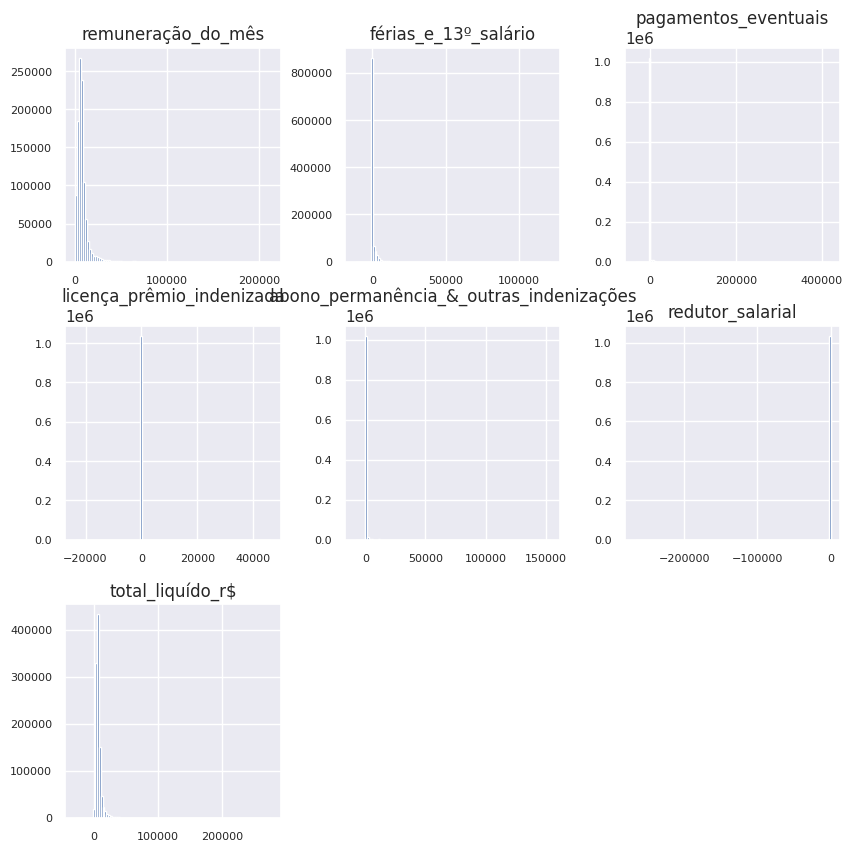

In [ ]:
numeric_df.hist(figsize=(10, 10), bins=100, xlabelsize=8, ylabelsize=8)

2.1. Gerando histogramas utilizando a Matplotlib

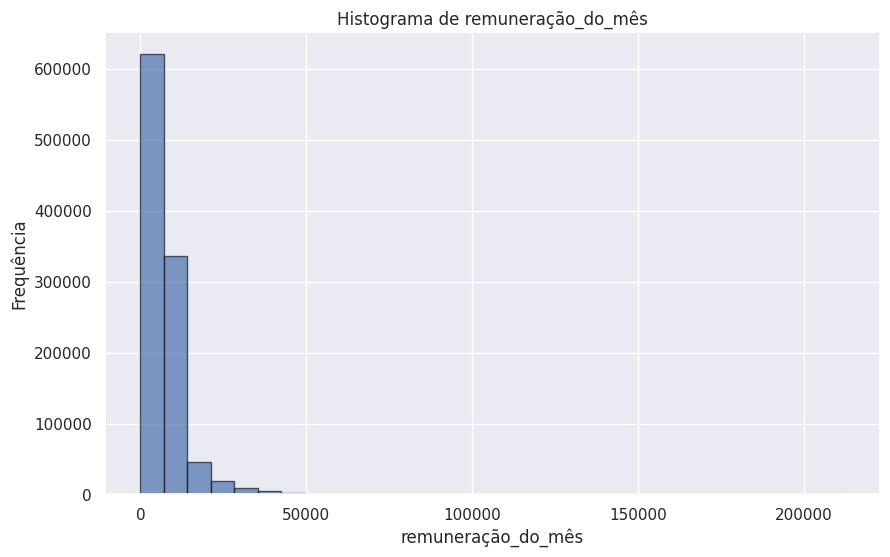

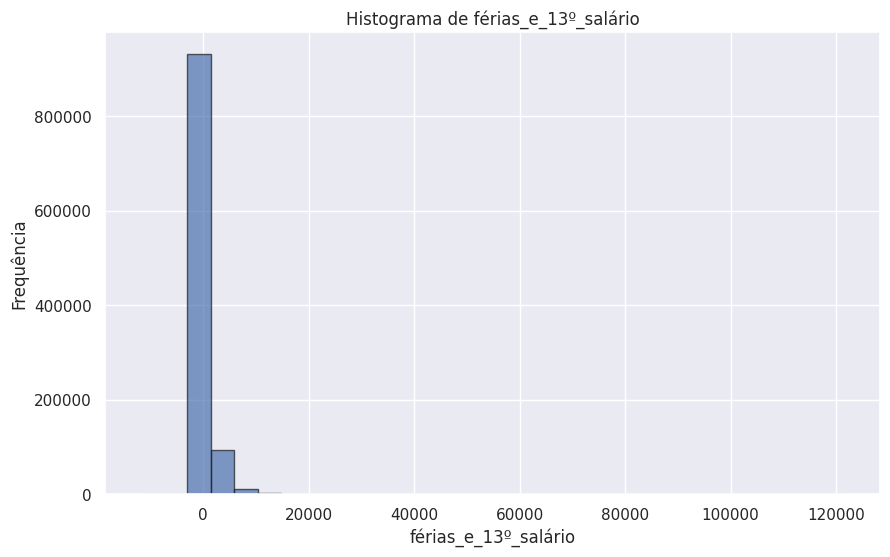

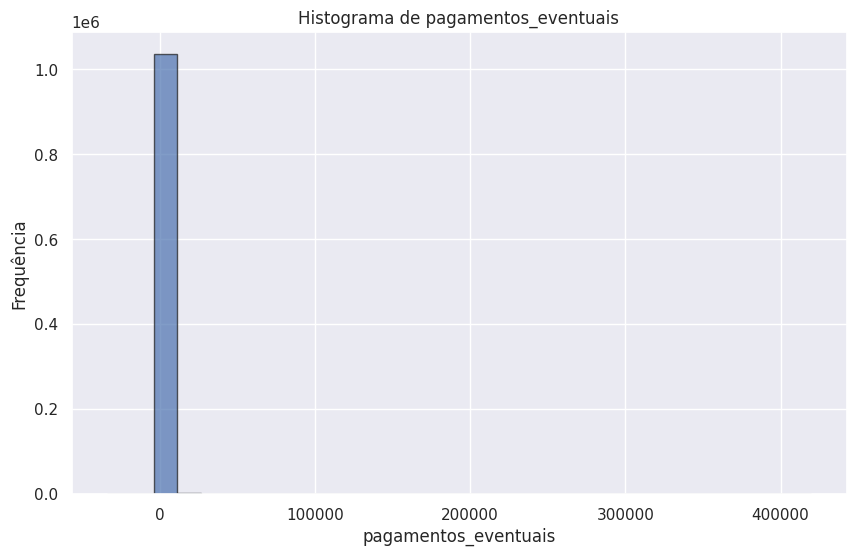

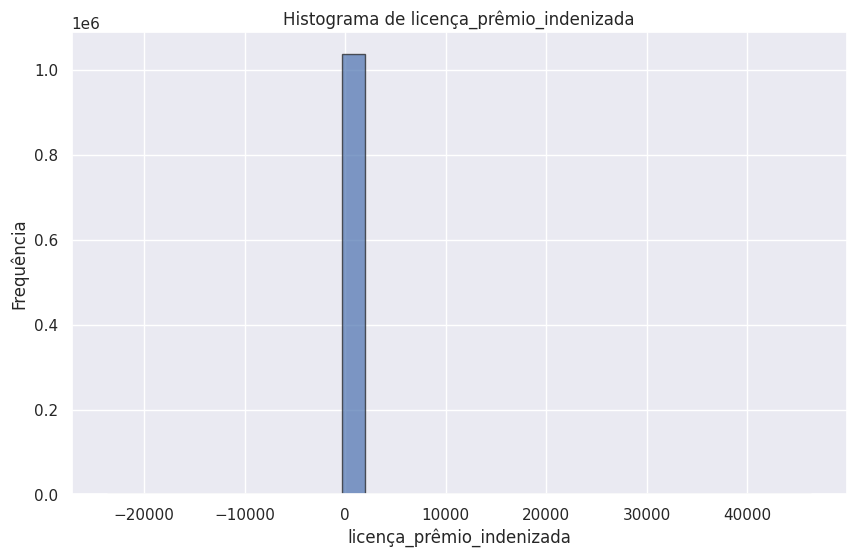

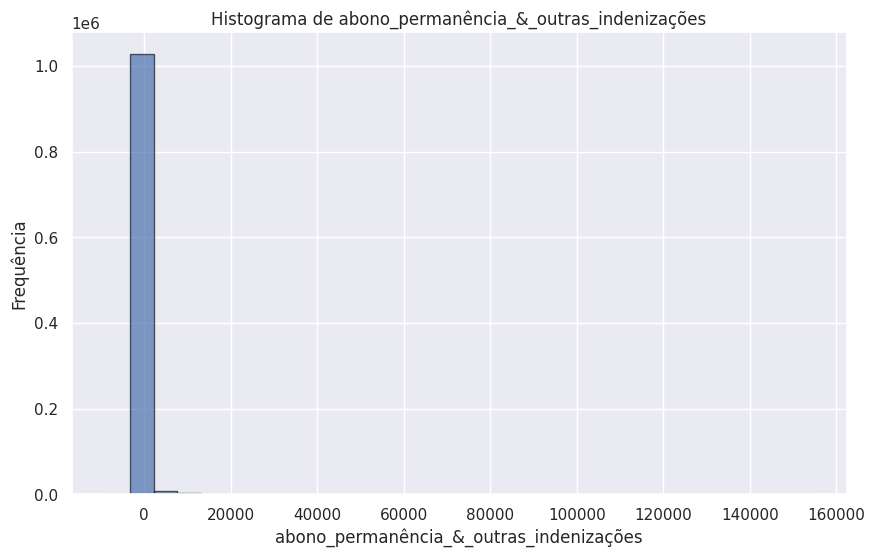

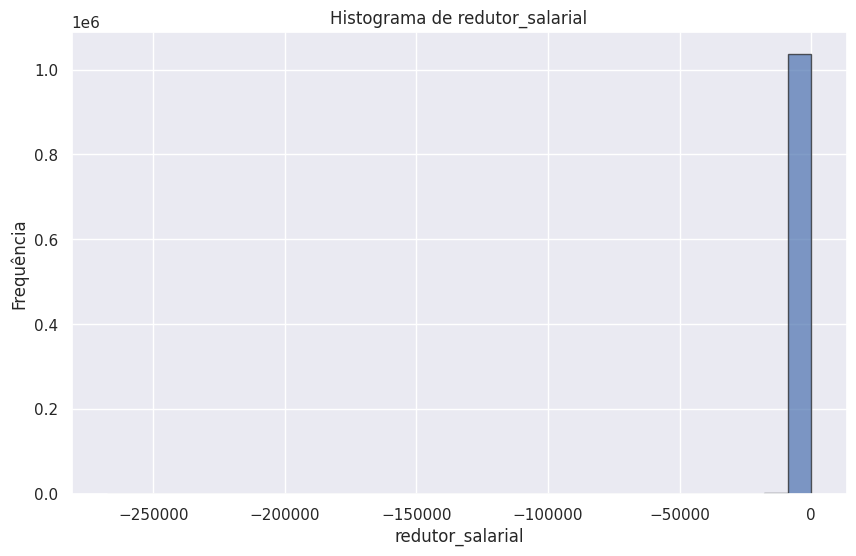

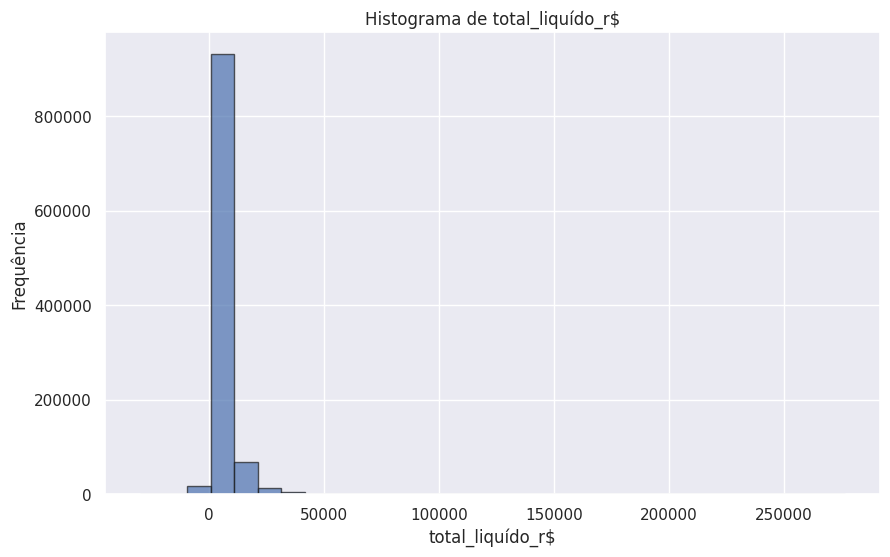

In [ ]:
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Gerar histogramas para cada coluna numérica
for column in numeric_df.columns:
    plt.figure(figsize=(10, 6))
    plt.hist(numeric_df[column].dropna(), bins=30, edgecolor='k', alpha=0.7)
    plt.title(f'Histograma de {column}')
    plt.xlabel(column)
    plt.ylabel('Frequência')
    plt.grid(True)
    plt.show()

Gerando histogramas utilizando a Seaborn

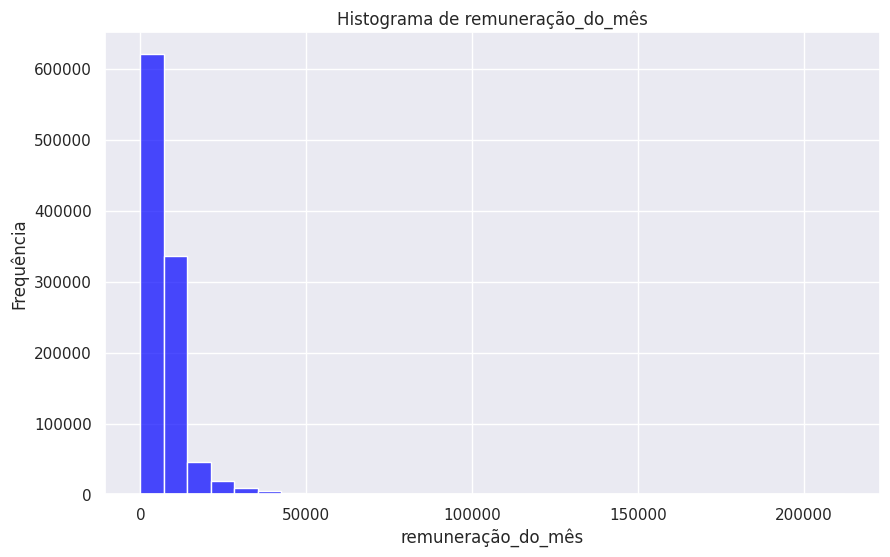

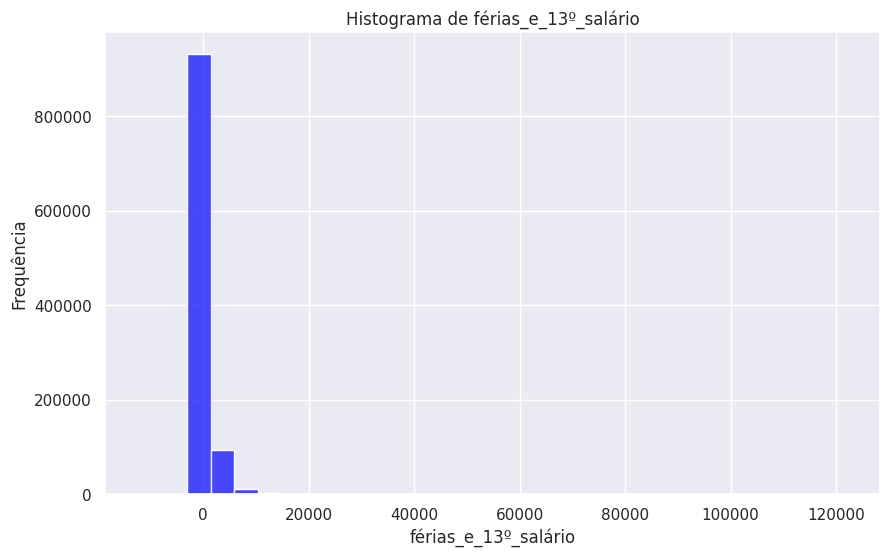

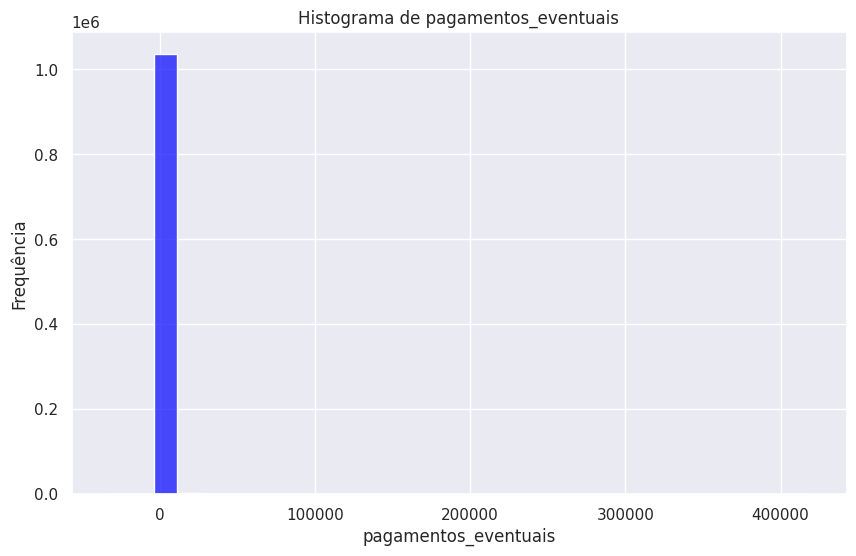

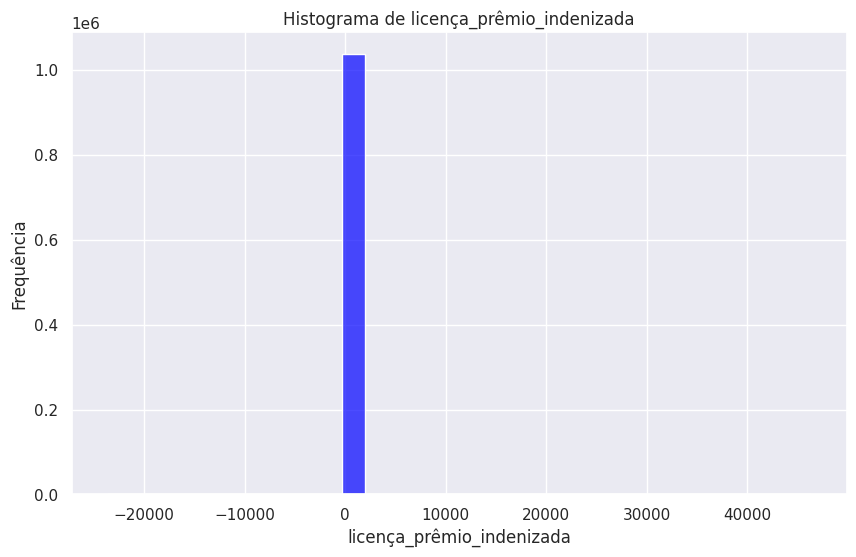

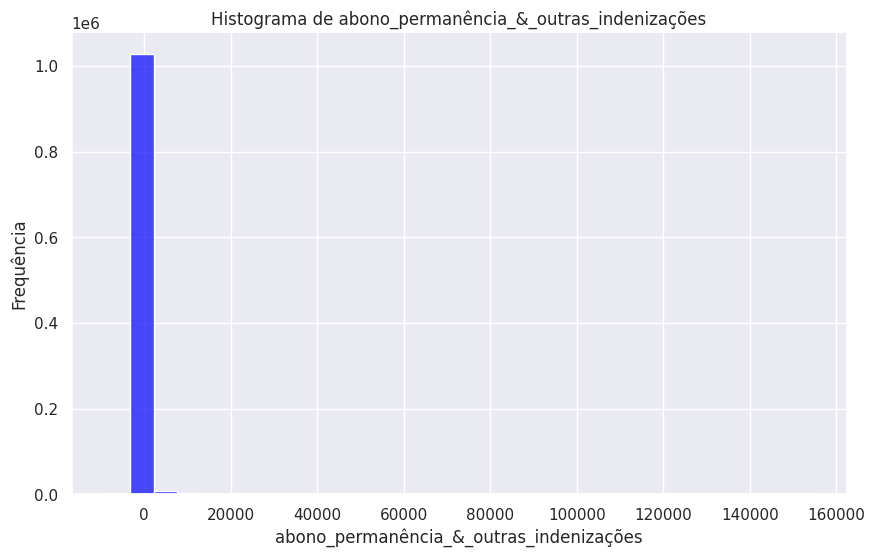

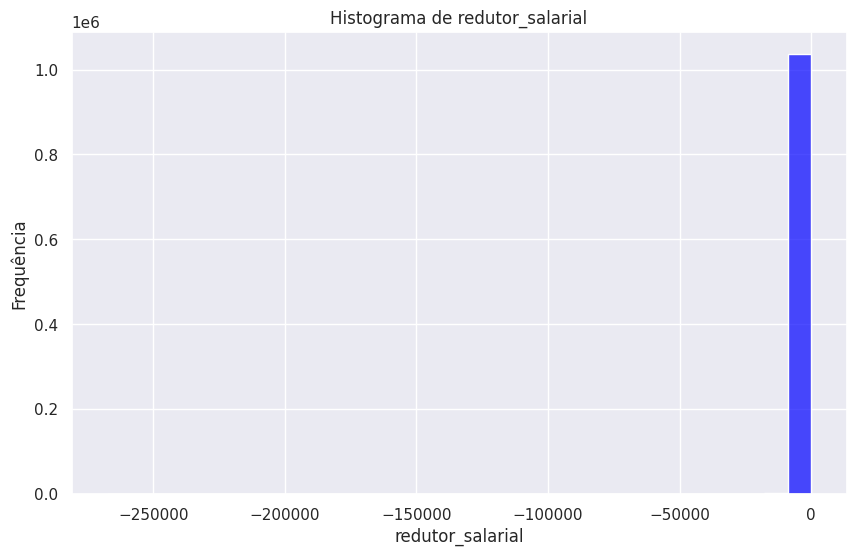

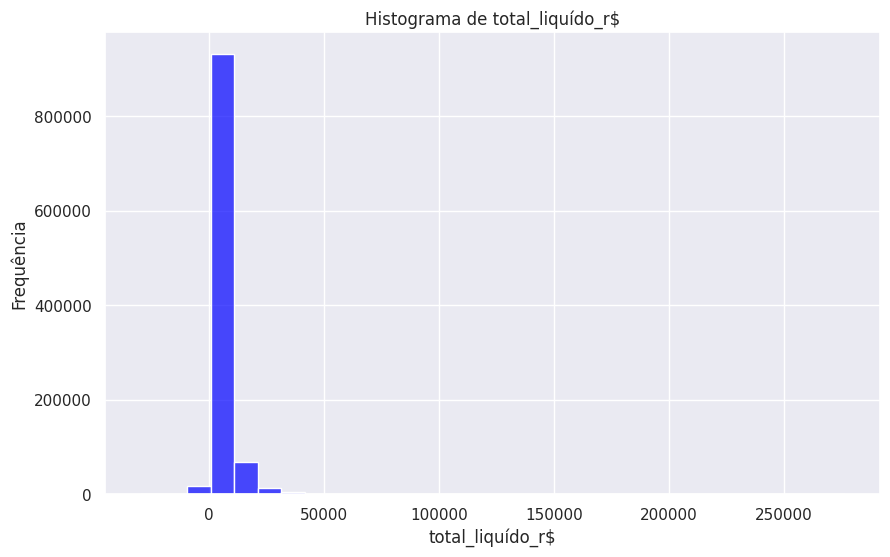

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Gerar histogramas para cada coluna numérica usando seaborn
for column in numeric_df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(numeric_df[column].dropna(), bins=30, kde=False, color='blue', alpha=0.7)
    plt.title(f'Histograma de {column}')
    plt.xlabel(column)
    plt.ylabel('Frequência')
    plt.grid(True)
    plt.show()

**Explicação:**
- plt.hist(): Cria um histograma básico usando matplotlib. O parâmetro bins define o número de intervalos no histograma, e edgecolor define a cor da borda dos bins.
- sns.histplot(): Cria um histograma usando seaborn, que também pode incluir uma estimativa da densidade de kernel (kde=True) se você desejar. O parâmetro color define a cor dos bins.
- O parâmetro alpha em visualizações como histogramas e gráficos de dispersão controla a transparência das barras ou pontos. O valor de alpha varia de 0 a 1, onde:
alpha = 0: Totalmente transparente.
alpha = 1: Totalmente opaco (sem transparência).

Ambos os métodos permitem visualizar a distribuição das variáveis numéricas no seu DataFrame. Ajuste o número de bins e outras opções conforme necessário para obter a visualização desejada.

**Observando em uma linha**

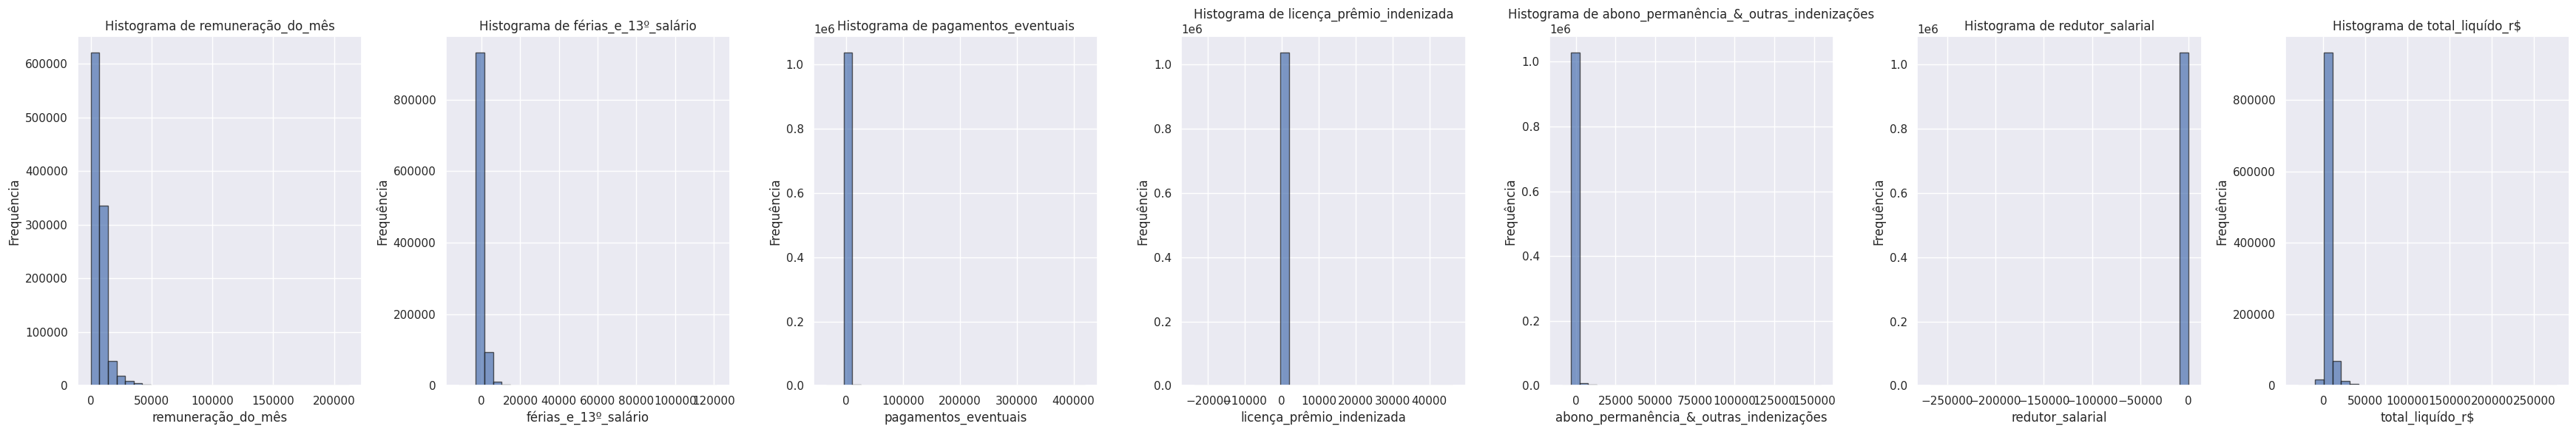

In [ ]:
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Definindo o número de subplots com base no número de colunas numéricas
num_vars = len(numeric_df.columns)
fig, axes = plt.subplots(1, num_vars, figsize=(5 * num_vars, 6))  # Ajuste o tamanho conforme necessário

# Gerar histogramas para cada coluna numérica
for ax, column in zip(axes, numeric_df.columns):
    ax.hist(numeric_df[column].dropna(), bins=30, edgecolor='k', alpha=0.7)
    ax.set_title(f'Histograma de {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequência')
    ax.grid(True)

# Ajustar o layout
plt.tight_layout()
plt.show()

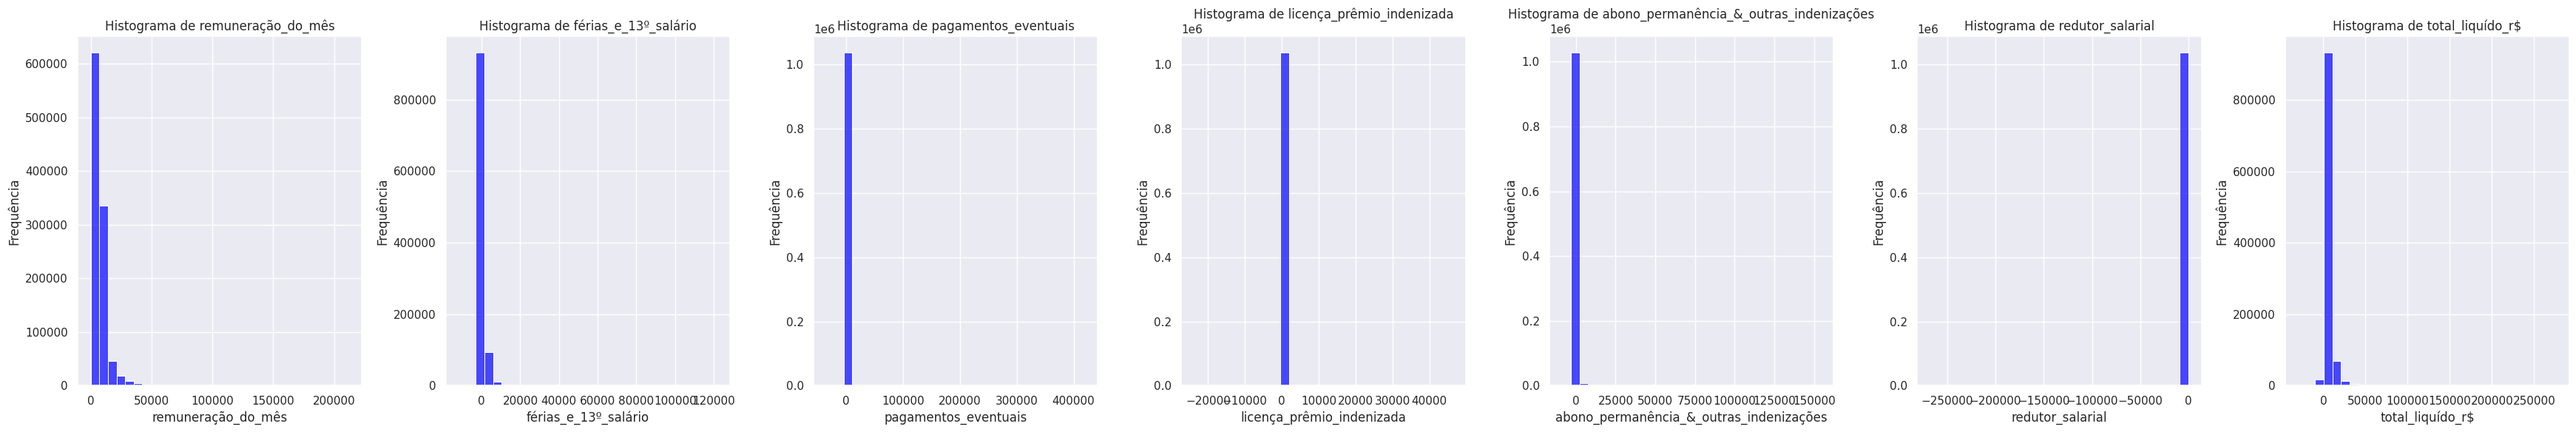

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Definindo o número de subplots com base no número de colunas numéricas
num_vars = len(numeric_df.columns)
fig, axes = plt.subplots(1, num_vars, figsize=(5 * num_vars, 6))  # Ajuste o tamanho conforme necessário

# Gerar histogramas para cada coluna numérica usando seaborn
for ax, column in zip(axes, numeric_df.columns):
    sns.histplot(numeric_df[column].dropna(), bins=30, kde=False, ax=ax, color='blue', alpha=0.7)
    ax.set_title(f'Histograma de {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequência')
    ax.grid(True)

# Ajustar o layout
plt.tight_layout()
plt.show()

# **3. Boxplots**

**Boxplots com Matplotlib**

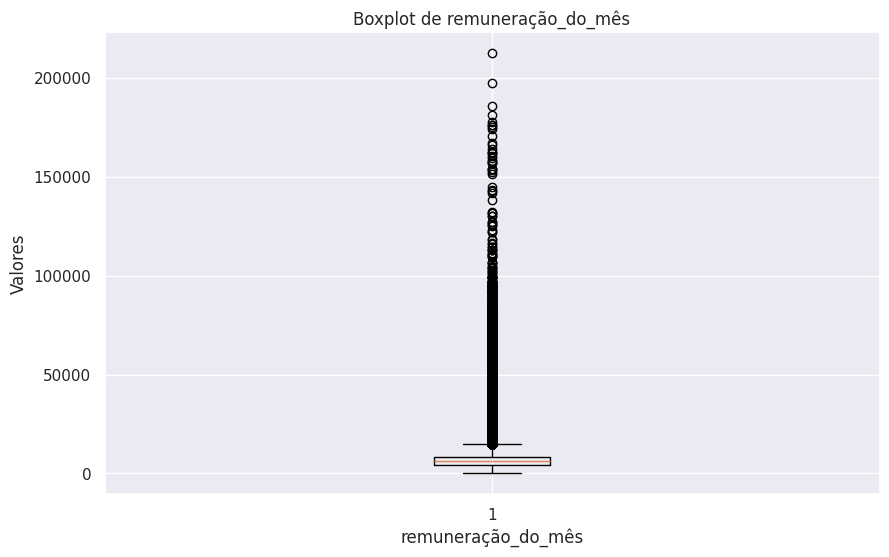

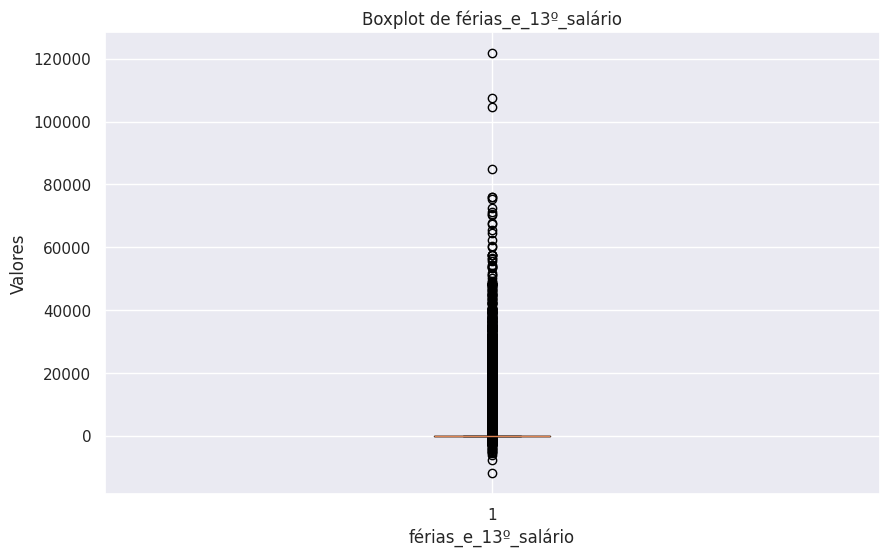

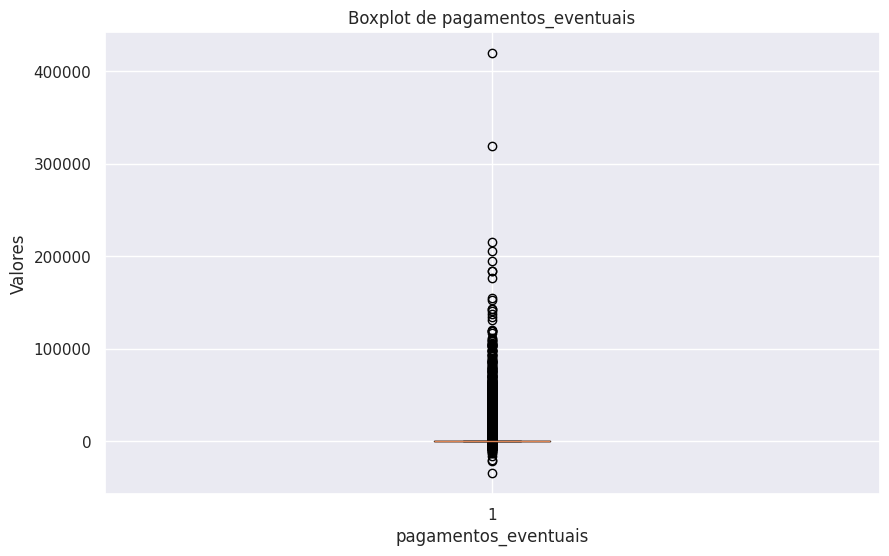

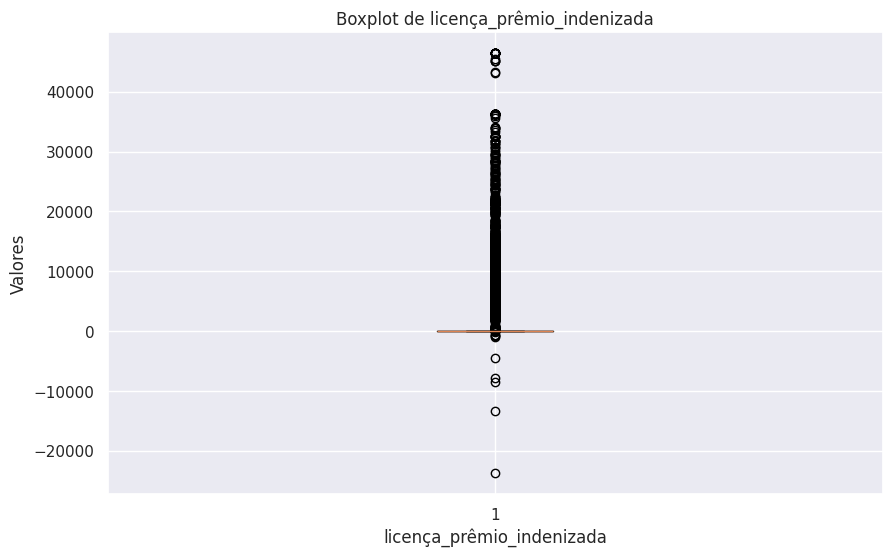

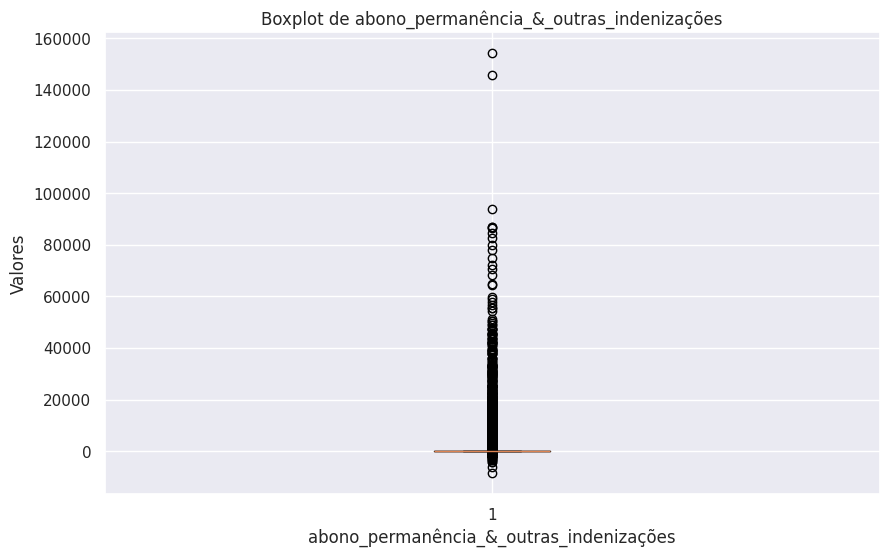

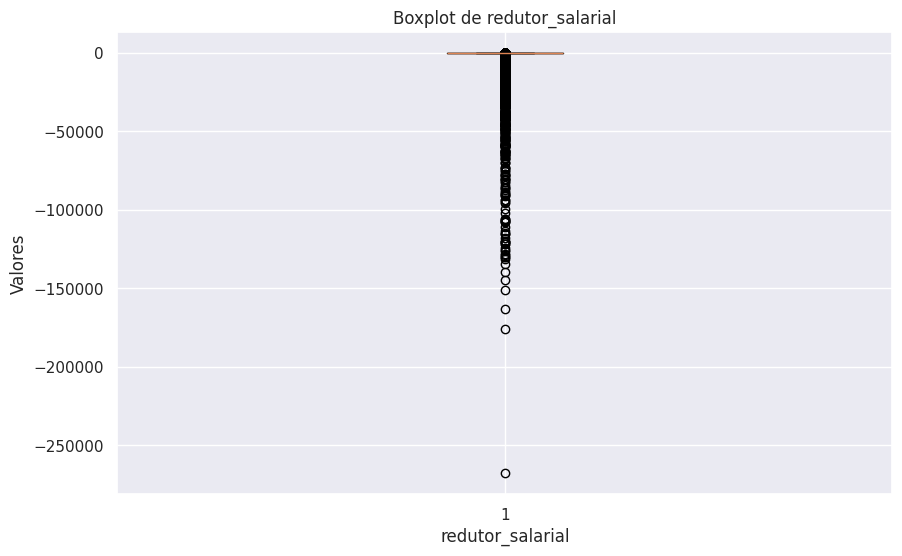

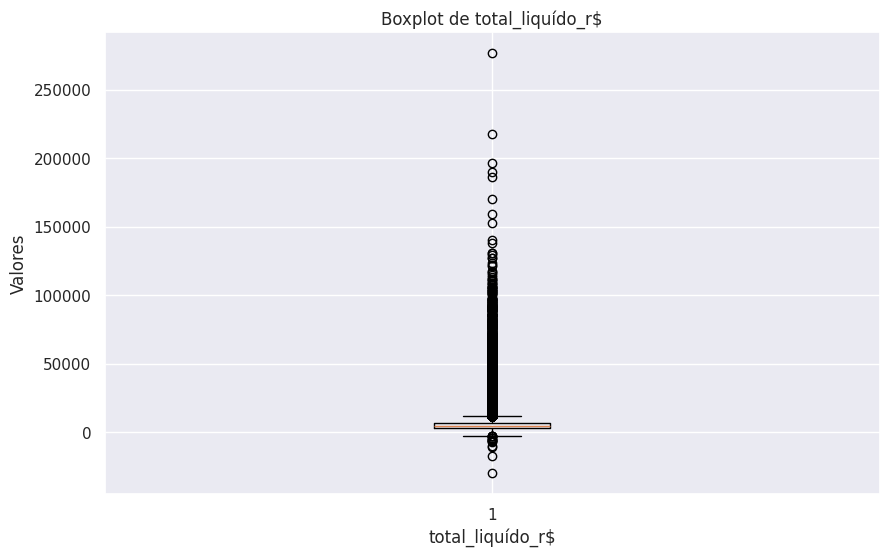

In [ ]:
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Gerar boxplots para cada coluna numérica
for column in numeric_df.columns:
    plt.figure(figsize=(10, 6))
    plt.boxplot(numeric_df[column].dropna())
    plt.title(f'Boxplot de {column}')
    plt.xlabel(column)
    plt.ylabel('Valores')
    plt.grid(True)
    plt.show()

**Boxplots com Seaborn**

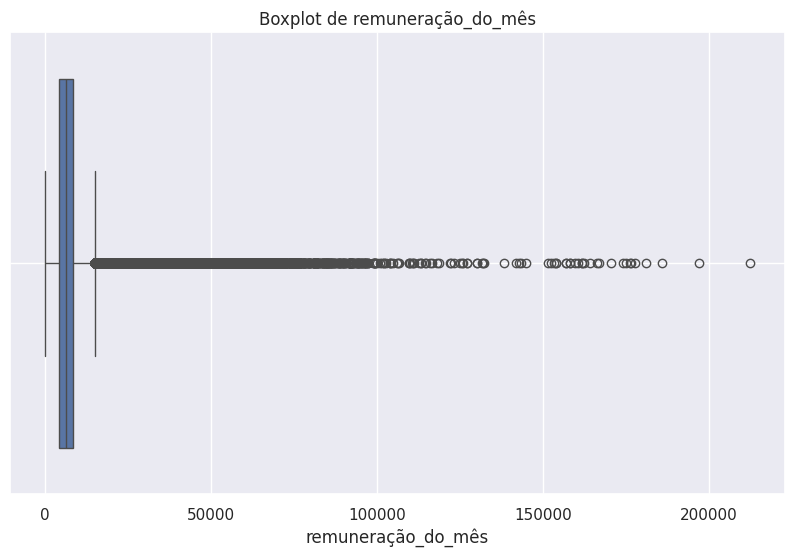

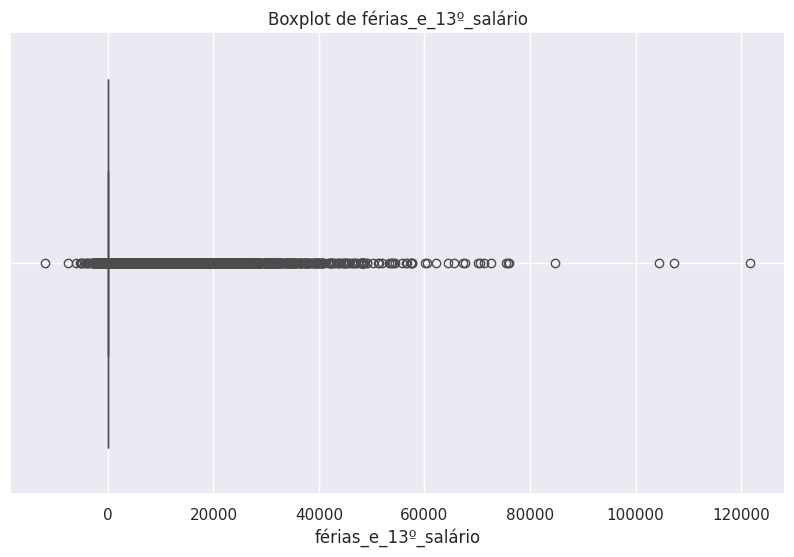

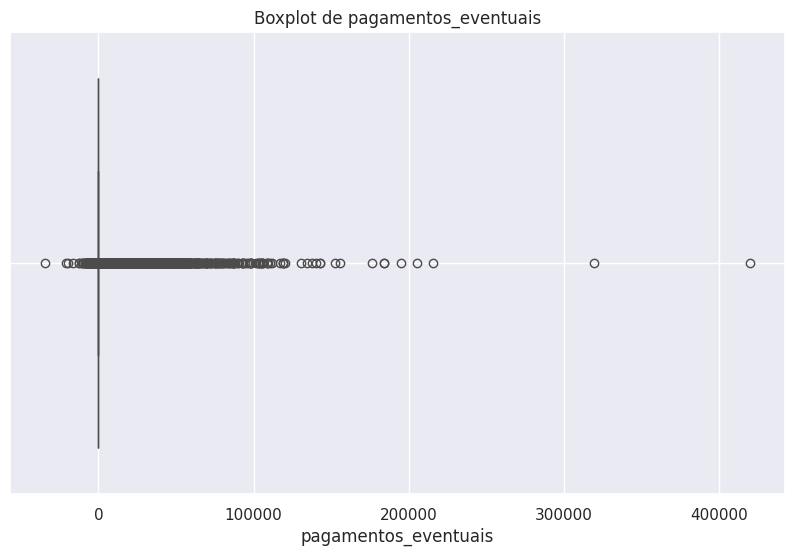

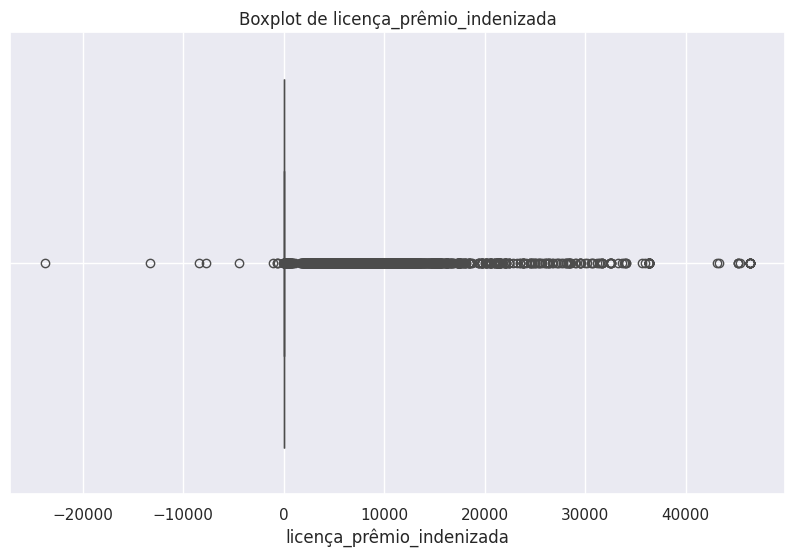

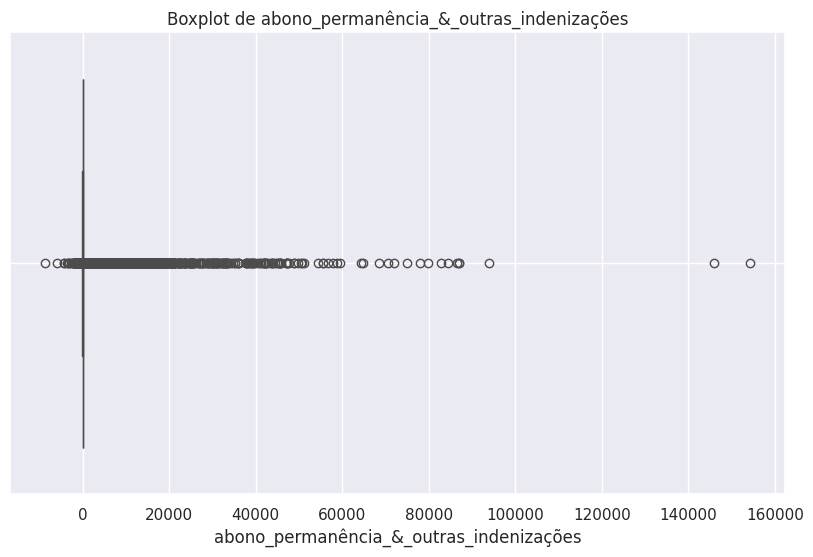

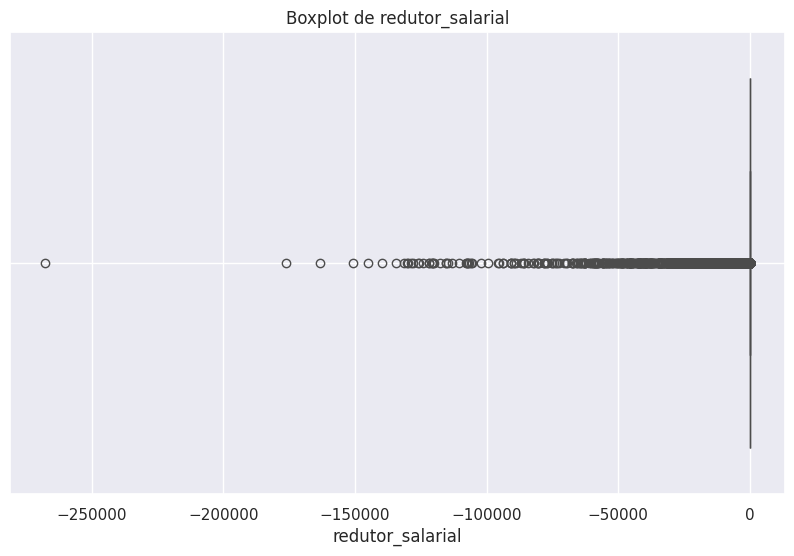

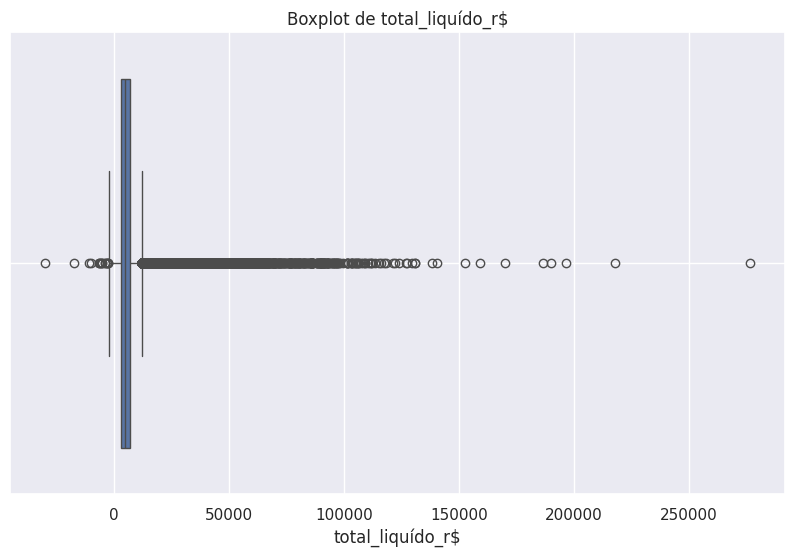

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Gerar boxplots para cada coluna numérica usando seaborn
for column in numeric_df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=numeric_df[column])
    plt.title(f'Boxplot de {column}')
    plt.xlabel(column)
    plt.grid(True)
    plt.show()

**Explicação:**
- plt.boxplot(): Cria um boxplot básico usando matplotlib. O boxplot exibe a mediana, os quartis e possíveis outliers dos dados.
- sns.boxplot(): Cria um boxplot usando seaborn, que oferece uma estética melhor e permite a inclusão de outras variáveis para comparação, se desejado.

Personalização Adicional
- plt.boxplot(): Permite várias personalizações, como adicionar notches (entrecortes) no boxplot para mostrar intervalos de confiança.
- sns.boxplot(): Permite incluir a estética da visualização e pode combinar facilmente com outras variáveis ou facetas.

Esses métodos permitirão visualizar a distribuição, a mediana, e os possíveis outliers para cada variável numérica no seu DataFrame.

**Observando em linha:**

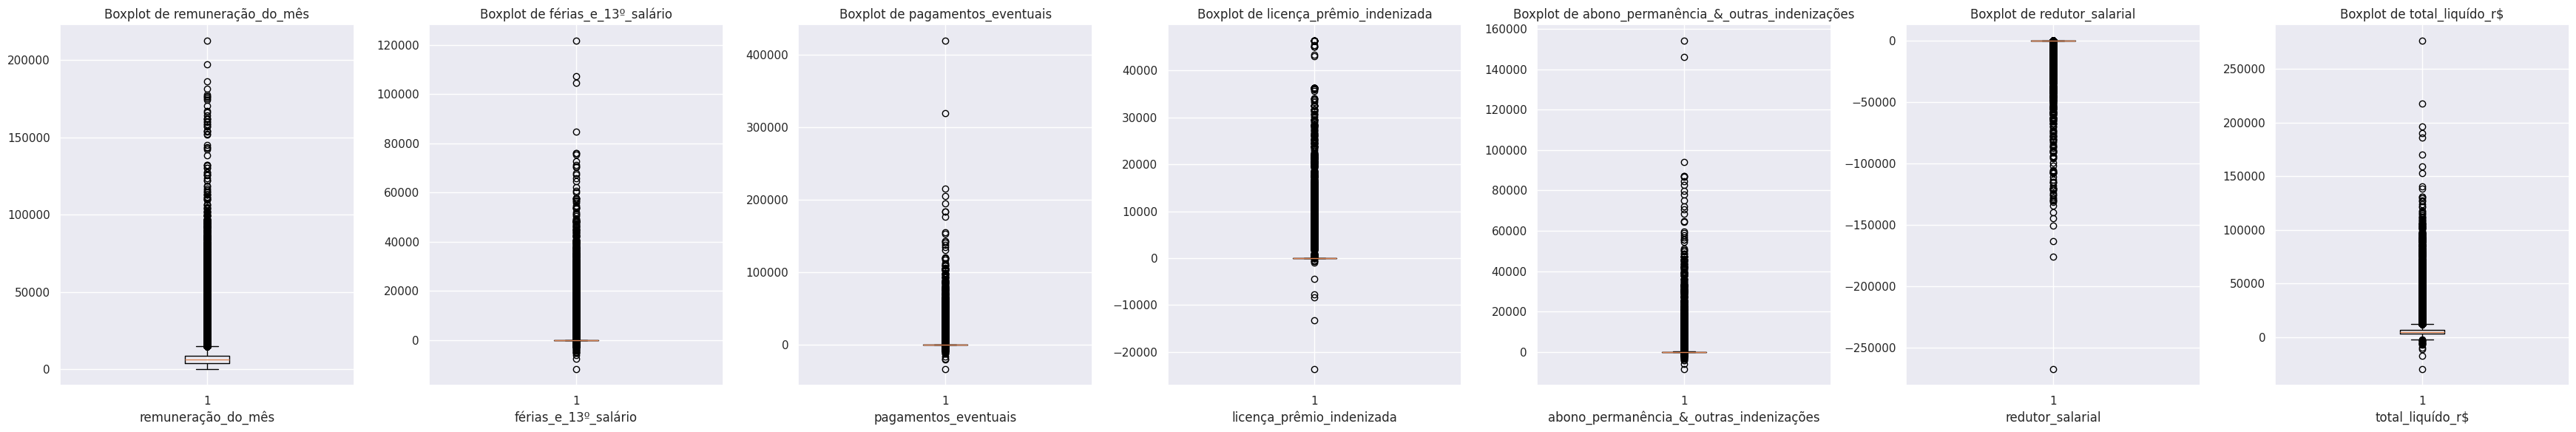

In [ ]:
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Definindo o número de subplots com base no número de colunas numéricas
num_vars = len(numeric_df.columns)
fig, axes = plt.subplots(1, num_vars, figsize=(5 * num_vars, 6))  # Ajuste o tamanho conforme necessário

# Gerar boxplots para cada coluna numérica
for ax, column in zip(axes, numeric_df.columns):
    ax.boxplot(numeric_df[column].dropna())
    ax.set_title(f'Boxplot de {column}')
    ax.set_xlabel(column)
    ax.grid(True)

# Ajustar o layout
plt.tight_layout()
plt.show()

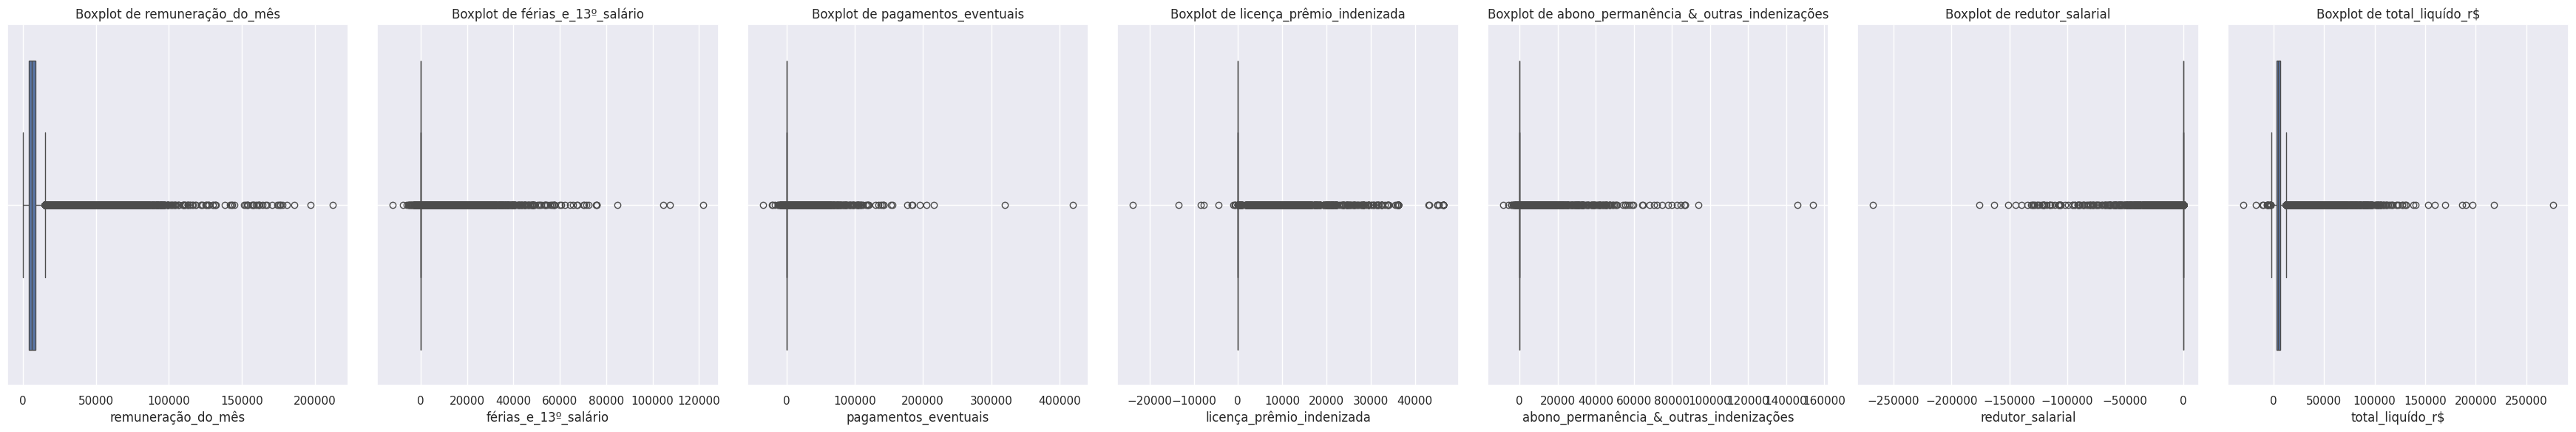

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Definindo o número de subplots com base no número de colunas numéricas
num_vars = len(numeric_df.columns)
fig, axes = plt.subplots(1, num_vars, figsize=(5 * num_vars, 6))  # Ajuste o tamanho conforme necessário

# Gerar boxplots para cada coluna numérica usando seaborn
for ax, column in zip(axes, numeric_df.columns):
    sns.boxplot(x=numeric_df[column], ax=ax)
    ax.set_title(f'Boxplot de {column}')
    ax.set_xlabel(column)
    ax.grid(True)

# Ajustar o layout
plt.tight_layout()
plt.show()

# **4. Discussão**

O que está acontecendo aqui?
Vamos ver:
 - O que acontece com esses salários negativos
 - O que acontece com os salários gigantes

# 4.1. Salários líquidos negativos

Isso deve ser resultado de redutor salarial, não acham?

Ganhou a mais, agora desconta.

In [ ]:
#Vamos ver os salários liquídos em relação ao redutor salarial
df[['total_liquído_r$', 'redutor_salarial']].sort_values(by='total_liquído_r$').head(10)

,total_liquído_r$,redutor_salarial
908391,-29980.96,0.0
53149,-17545.07,0.0
169483,-10978.90,0.0
455282,-9943.96,0.0
184676,-6739.02,0.0
132269,-6446.46,0.0
215762,-6102.54,0.0
507697,-5784.82,0.0
9774,-5387.73,0.0
655010,-5263.38,0.0


De onde vieram esses salários negativos?

In [ ]:
cols = [
    'remuneração_do_mês',
    'férias_e_13º_salário',
    'pagamentos_eventuais',
    'licença_prêmio_indenizada',
    'abono_permanência_&_outras_indenizações',
    'redutor_salarial',
    'total_liquído_r$'
]

df.loc[
    df['total_liquído_r$'] < 0,
    cols
].head(10)

,remuneração_do_mês,férias_e_13º_salário,pagamentos_eventuais,licença_prêmio_indenizada,abono_permanência_&_outras_indenizações,redutor_salarial,total_liquído_r$
9774,0.00,2719.30,-9740.42,0.0,0.00,0.0,-5387.73
10889,3478.12,0.00,-4917.19,0.0,109.91,0.0,-1904.27
29312,540.48,0.00,-232.27,0.0,0.00,0.0,-2485.95
33686,0.00,0.00,-264.37,0.0,0.00,0.0,-472.46
53149,0.00,0.00,-20943.77,0.0,0.00,0.0,-17545.07
60629,0.00,0.00,1093.09,0.0,0.00,0.0,-695.16
73835,6747.83,0.00,-5412.10,0.0,0.00,0.0,-674.78
128125,540.48,0.00,0.00,0.0,0.00,0.0,-405.80
132269,7791.00,0.00,-12350.93,0.0,0.00,0.0,-6446.46
133085,0.00,952.35,-1275.31,0.0,0.00,0.0,-221.89


Parece que encontramos, coluna pagamentos_eventuais.

In [ ]:
#Vamos ver os salários liquídos em relação ao redutor salarial
df[['total_liquído_r$', 'pagamentos_eventuais']].sort_values(by='total_liquído_r$').head(10)

,total_liquído_r$,pagamentos_eventuais
908391,-29980.96,-34295.59
53149,-17545.07,-20943.77
169483,-10978.90,-16439.63
455282,-9943.96,0.00
184676,-6739.02,-6715.58
132269,-6446.46,-12350.93
215762,-6102.54,915.37
507697,-5784.82,0.00
9774,-5387.73,-9740.42
655010,-5263.38,6584.74


Isso é raro… ou é frequente?

In [ ]:
(df['total_liquído_r$'] < 0).sum()

np.int64(50)

Vamos olhar a estatística descritiva desses 50 sujeitos:

In [ ]:
df[df['total_liquído_r$'] < 0]['total_liquído_r$'].describe()

,total_liquído_r$
count,50.000000
mean,-3058.903600
std,5105.704557
min,-29980.960000
25%,-2974.017500
50%,-1250.415000
75%,-477.717500
max,-52.270000


**Já imaginou isso indo para algum modelo??**

Quais situações podem gerar salário líquido negativo em folha de pagamento pública?
- Pergunte a LLM

Solução?

In [ ]:
#Eu só separaria os negativos por enquanto, até entender o que é isso
df_negativos = df[df['total_liquído_r$'] < 0]
df_positivos = df[df['total_liquído_r$'] >= 0]

Sobre a LLM aqui vai a resposta da minha:
- Veja a associação das variáveis

In [ ]:
df[['total_liquído_r$', 'pagamentos_eventuais']].corr()

,total_liquído_r$,pagamentos_eventuais
total_liquído_r$,1.000000,0.305855
pagamentos_eventuais,0.305855,1.000000


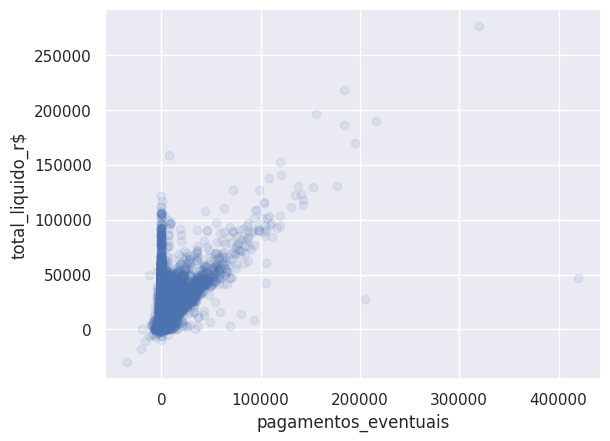

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['pagamentos_eventuais'], df['total_liquído_r$'], alpha=0.1)
plt.xlabel('pagamentos_eventuais')
plt.ylabel('total_liquido_r$')
plt.show()

**O que descobrimos?**
- O salário líquido é altamente sensível a pagamentos_eventuais
- Se eu ignorar essa variável minha análise fica correta? (não)
- Variáveis com nome ‘eventual’
podem ser as mais importantes do dataset
- Nem tudo que parece bônus… é bônus

**Temos como ter certeza da causa disso?**

HIPÓTESES MAIS PROVÁVEIS
1. Estorno de pagamento anterior
pagaram errado
estão descontando agora
2. Ajuste administrativo
correção de folha
decisão judicial
3. Lançamento acumulado
múltiplos ajustes em um mês

# 4.2. Salários liquídos gigantes

In [ ]:
#Vamos ver quem são, estamos só filtrando planilha aqui (só que uma de meio milhão de linhas)
df_top = df.sort_values(by='total_liquído_r$', ascending=False).head(10)
df_top

,nome,cargo,orgão,remuneração_do_mês,férias_e_13º_salário,pagamentos_eventuais,licença_prêmio_indenizada,abono_permanência_&_outras_indenizações,redutor_salarial,total_liquído_r$,grupo
354141,GERALDO NOGUEIRA DA ROCHA FILH,PERITO CRIMINAL CL.ESPECIAL,SAO PAULO PREVIDENCIA SPPREV,26656.10,24413.41,319547.23,0.0,0.00,0.0,276522.12,APOSENTADOS
761390,NELSON MASSAO KANASHIRO,PROFESSOR DE ENSINO SUPERIOR,"CTRO.EST.ED.TEC.""P.SO"" CEETEPS",38878.37,15146.60,184052.27,0.0,0.00,0.0,218050.59,ATIVOS
776320,NORBERTO NERY,PROFESSOR DE ENSINO SUPERIOR,"CTRO.EST.ED.TEC.""P.SO"" CEETEPS",40486.47,13323.93,155385.00,0.0,0.00,0.0,196522.55,ATIVOS
683394,MARIA NEUSA GONINI BENICIO,PROFESSOR EDUCA O B SICA II,SAO PAULO PREVIDENCIA SPPREV,6097.13,13807.03,215681.82,0.0,0.00,0.0,190254.28,APOSENTADOS
580502,MARAISA PAULO ROLDAO,BENEFICIARIO DA POLICIA MILITAR - CBPM,SAO PAULO PREVIDENCIA SPPREV,16753.28,16288.85,184166.37,0.0,0.00,0.0,186398.87,PENSIONISTAS
631576,MARIA CARMEM FONTES SANSON,COMPLEM PENSAO - BANCO NOSSA CAIXA,ADMINISTRACAO GERAL DO ESTADO,34403.27,0.00,195325.56,0.0,0.00,0.0,170047.35,PENSIONISTAS
33720,ALEXANDRE POLITO FERREIRA,DELEGADO POLICIA 1A CLASSE,SECRETARIA SEGURANCA PUBLICA,27072.74,4512.12,7851.37,0.0,154185.53,0.0,159201.24,ATIVOS
894575,SALVADOR BENEDITO SAMPAIO,PROFESSOR DE ENSINO SUPERIOR,"CTRO.EST.ED.TEC.""P.SO"" CEETEPS",28892.59,9316.90,119167.27,0.0,0.00,0.0,152739.20,ATIVOS
383586,HELVIO FREGOLENTE JUNIOR,PROFESSOR DE ENSINO SUPERIOR,"CTRO.EST.ED.TEC.""P.SO"" CEETEPS",18526.36,6967.88,120463.10,0.0,0.00,0.0,140329.66,ATIVOS
788239,OSWALDO TADAMI ARIMURA,PROFESSOR DE ENSINO SUPERIOR,"CTRO.EST.ED.TEC.""P.SO"" CEETEPS",25134.63,9488.05,108708.12,0.0,0.00,0.0,138299.33,ATIVOS


E ai LLM? O que isso significa?

**Esses casos têm padrão muito interessante:**
- O driver principal NÃO é salário base
- remuneração_do_mês → 6k a 40k
- total_liquido → 200k+

**impossível vir do salário base**

- Quem está dominando?

👉 pagamentos_eventuais
👉 indenizações

**CONCLUSÃO PRINCIPAL**

🔥 Esses valores NÃO são salários mensais
🔥 São eventos extraordinários acumulados

**Grupo dominante:**

PERITO CRIMINAL CL.ESPECIA – SAO PAULO PREVIDENCIA SPPREV

PROFESSOR DE ENSINO SUPERIOR - CTRO.EST.ED.TEC."P.SO" CEETEPS

**Por que esse grupo específico aparece tanto?**

🧠 HIPÓTESES FORTES
1. 🔥 Pagamentos retroativos
acúmulo de meses/anos
2. 🔥 Ações judiciais
decisões liberando valores
3. 🔥 Indenizações acumuladas
férias
benefícios
4. 🔥 Mudança de regime/contrato

In [ ]:
df_top['cargo'].value_counts()

,count
cargo,
PROFESSOR DE ENSINO SUPERIOR,5
PERITO CRIMINAL CL.ESPECIAL,1
PROFESSOR EDUCA O B SICA II,1
BENEFICIARIO DA POLICIA MILITAR - CBPM,1
COMPLEM PENSAO - BANCO NOSSA CAIXA,1
DELEGADO POLICIA 1A CLASSE,1


###Desse TOP10 como está distribuido nos Grupos

In [ ]:
df_top['grupo'].value_counts()

,count
grupo,
ATIVOS,6
APOSENTADOS,2
PENSIONISTAS,2


### Renumeração do mês de acordo com o Cargo

In [ ]:
df.groupby('cargo')['remuneração_do_mês'].mean().sort_values(ascending=False).head(10)

,remuneração_do_mês
cargo,
COMPLEMENTACAO APOSENTAD - DER,98962.990000
PROCURADOR AUTARQ. ASSISTENTE,71386.050000
PROCURADOR DE AUTARQUIA CHEFE,70161.483333
PROCURADOR DE AUTARQUIA I,68672.750000
PROCURADOR NIVEL IV,66971.710000
PROCURADOR NIVEL V,66544.040000
PROCURADOR DO ESTADO NIVEL V,65809.497492
PROCURADOR ESTADO CORREG.GERAL,64429.880000
PROCURADOR DE AUTARQUIA IV,64318.913333


### Quantos pagamentos eventuais foram realizados acima de 100k?

In [ ]:
(df['pagamentos_eventuais'] > 100000).sum()

np.int64(36)

MOMENTO LLM

Quais situações explicam pagamentos eventuais muito altos em servidores públicos?

# **5. Mergulho profundo**

Nós vamos agora tentar entender como as colunas contribuem para o total líquido

**1 — Criar as proporções**

In [ ]:
componentes = [
    'remuneração_do_mês',
    'férias_e_13º_salário',
    'pagamentos_eventuais',
    'licença_prêmio_indenizada',
    'abono_permanência_&_outras_indenizações',
    'redutor_salarial'
]

for col in componentes:
    df[f'perc_{col}'] = df[col] / df['total_liquído_r$']

In [ ]:
#Pode ter zeros, isso aqui evita divisão por zero
for col in componentes:
    df[f'perc_{col}'] = df[col] / df['total_liquído_r$'].replace(0, None)

**2 — Analisando salários mais altos**

Aqui estamos vendo proporcionalmente os salários extremos, veja que interessante:

In [ ]:
df_top = df.sort_values(by='total_liquído_r$', ascending=False).head(10)

cols_perc = [f'perc_{col}' for col in componentes]

df_top[cols_perc]

,perc_remuneração_do_mês,perc_férias_e_13º_salário,perc_pagamentos_eventuais,perc_licença_prêmio_indenizada,perc_abono_permanência_&_outras_indenizações,perc_redutor_salarial
354141,0.096398,0.088287,1.155594,0.0,0.0,0.0
761390,0.1783,0.069464,0.844081,0.0,0.0,0.0
776320,0.206014,0.067798,0.790673,0.0,0.0,0.0
683394,0.032047,0.072571,1.13365,0.0,0.0,0.0
580502,0.089879,0.087387,0.988023,0.0,0.0,0.0
631576,0.202316,0.0,1.148654,0.0,0.0,0.0
33720,0.170054,0.028342,0.049317,0.0,0.968495,0.0
894575,0.189163,0.060999,0.780201,0.0,0.0,0.0
383586,0.13202,0.049654,0.858429,0.0,0.0,0.0
788239,0.181741,0.068605,0.786035,0.0,0.0,0.0


O que acha, conorda?
 - pagamentos_eventuais → dominante
 - abonos grandes
 - salário base pequeno proporcionalmente

**3 - Visão global**

In [ ]:
df[cols_perc].mean().sort_values(ascending=False)

,0
perc_remuneração_do_mês,7.058466
perc_férias_e_13º_salário,1.028157
perc_abono_permanência_&_outras_indenizações,0.029369
perc_pagamentos_eventuais,0.01797
perc_licença_prêmio_indenizada,0.0016
perc_redutor_salarial,-0.005952


**Esses valores não deveriam somar ~1?**
 - totais muito pequenos / negativos
 - proporções “explodindo”
 - efeito de divisão instável

Veja as proporções dos super salários:

In [ ]:
df_extremos = df[df['total_liquído_r$'] > 100000]

df_extremos[cols_perc].mean()

,0
perc_remuneração_do_mês,0.332857
perc_férias_e_13º_salário,0.143763
perc_pagamentos_eventuais,0.604969
perc_licença_prêmio_indenizada,0.140686
perc_abono_permanência_&_outras_indenizações,0.055069
perc_redutor_salarial,-0.028036


Veja que temos uma tendência diferente.


 - **Isso significa que não podemos analisar tudo junto?**

- **Estamos olhando um único fenômeno, ou vários fenômenos misturados?**

- **Se eu treinar um modelo com tudo junto…
ele aprende o quê?**

**TRADUÇÃO CONCEITUAL**

🔹 Dataset geral:
dominado por salário base
comportamento “normal”

🔹 Extremos:
dominados por eventos
comportamento “anômalo” (mas real)

Possível solução:
- Separar os eventos

In [ ]:
df_normal = df[df['pagamentos_eventuais'] < 10000]
df_evento = df[df['pagamentos_eventuais'] >= 10000]

Não esqueça que deixamos os negativos la atrás separados

# **6. Critérios de fracionamento usando estatística**

Nós vamo sutilizar tecnicoas de remoção de outliers para visualizar como seria o dataset sem esses extremos.

Essa é uma etapa comum na limpeza e pré-processamento de dados. Mas sempre cuidado, pois os extremos podem carregar informações importantes, como observamos nas etapas anteriores.

Existem várias maneiras de identificar e remover outliers, porém a existência de um outlier não necessáriamente indica que o dado precisa ser removido.

Atenção em cuidado na análise dos outliers antes de remove-los.

    Desvio Padrão
    Intervalo Interquartil (IQR)
    Boxplots - já utilizamos
   
Sempre busque analisar e visualizar os Outliers antes de remove-los, realize a análise variável por variável, e se for necessário, utilizando o dataframe completo.

# **6.1 Abordagem utilizando IQR**

**Removendo utilizando o Intervalo Interquartil (IQR)**

Uma abordagem que considerara dados que estão acima ou abaixo do IQR como outliers.

Explicação:
- Calcular Q1, Q3 e IQR: Calcula o primeiro quartil (Q1), o terceiro quartil (Q3) e o intervalo interquartil (IQR) para a coluna especificada.
- Definir Limite Superior:
Valores acima desse limite são considerados outliers superiores.
- Definir Limite Inferior:
Valores acima abaixo limite são considerados outliers inferiores.
- Filtrar o DataFrame: Filtra o DataFrame para manter apenas as linhas onde o valor na coluna especificada é menor ou igual ao limite superior.
- Depois salvamos os extremos e removemos do dataset

**6.1 Abordagem utilizando IQR - para outliers superiores ao IQR.**

In [ ]:
def filter_above_iqr_for_column(df, column_name):
    # Calcular Q1, Q3 e IQR
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1

    # Limite superior
    upper_bound = Q3 + 1.5 * IQR

    # Filtrar valores acima do limite superior
    column_outliers = df[df[column_name] > upper_bound]

    return column_outliers

# Filtrar valores superiores ao IQR para a coluna 'XXXX'
outliers_up = filter_above_iqr_for_column(df, 'total_liquído_r$')

# Exibir os resultados
print("Valores superiores ao IQR na coluna 'total_liquído_r$':")
outliers_up

Valores superiores ao IQR na coluna 'total_liquído_r$':


,nome,cargo,orgão,remuneração_do_mês,férias_e_13º_salário,pagamentos_eventuais,licença_prêmio_indenizada,abono_permanência_&_outras_indenizações,redutor_salarial,total_liquído_r$,grupo,perc_remuneração_do_mês,perc_férias_e_13º_salário,perc_pagamentos_eventuais,perc_licença_prêmio_indenizada,perc_abono_permanência_&_outras_indenizações,perc_redutor_salarial
37,ABAETE FERREIRA DA SILVA,STEN PM,SAO PAULO PREVIDENCIA SPPREV,12360.16,6180.08,0.00,0.0,0.00,0.00,13433.98,APOSENTADOS,0.920067,0.460033,0.0,0.0,0.0,0.0
41,ABARE LUAMIR PEREIRA DA SILVA,AGENTE DE AP SOCIOEDUCAT III,FUNDACAO CASA-SP.,15037.12,5389.48,0.00,0.0,468.07,0.00,15342.36,ATIVOS,0.980105,0.351281,0.0,0.0,0.030508,0.0
42,ABARE VAZ DE LIMA,CEL PM,SAO PAULO PREVIDENCIA SPPREV,43338.35,0.00,0.00,0.0,0.00,-5378.92,16462.82,APOSENTADOS,2.632499,0.0,0.0,0.0,0.0,-0.326731
47,ABBOUD ZAKI BADR TANNOUS,AUDITOR FISCAL DA RECEITA ESTA,SAO PAULO PREVIDENCIA SPPREV,40624.98,0.00,0.00,0.0,0.00,-4323.45,23547.03,APOSENTADOS,1.72527,0.0,0.0,0.0,0.0,-0.183609
59,ABDALA HEDJAZI,AUDITOR FISCAL DA RECEITA ESTA,SAO PAULO PREVIDENCIA SPPREV,35539.34,0.00,0.00,0.0,0.00,0.00,31078.23,APOSENTADOS,1.143545,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039589,ZULMIRA MARIA JACOMELI PEREIRA,PROFESSOR EDUCA O B SICA I,SAO PAULO PREVIDENCIA SPPREV,11124.72,0.00,5562.36,0.0,0.00,0.00,14178.81,APOSENTADOS,0.784602,0.0,0.392301,0.0,0.0,0.0
1039615,ZULMIRA PANUCHI DANTAS,BENEFICIARIO DA POLICIA MILITAR - CBPM,SAO PAULO PREVIDENCIA SPPREV,26408.84,0.00,0.00,0.0,0.00,0.00,19043.98,PENSIONISTAS,1.386729,0.0,0.0,0.0,0.0,0.0
1039624,ZULMIRA PIMENTEL GANDA,BENEFICIARIO DE SERVIDOR ESTADUAL-IPESP,SAO PAULO PREVIDENCIA SPPREV,22177.12,0.00,0.00,0.0,0.00,0.00,15884.45,PENSIONISTAS,1.396153,0.0,0.0,0.0,0.0,0.0
1039634,ZULMIRA RODRIGO TORRECILHAS,PROFESSOR DE ENSINO SUPERIOR,"CTRO.EST.ED.TEC.""P.SO"" CEETEPS",11800.57,4588.24,0.00,0.0,0.00,0.00,12791.31,ATIVOS,0.922546,0.3587,0.0,0.0,0.0,0.0


**6.2. Abordagem utilizando IQR - para outliers inferiores ao IQR.**

In [ ]:
def filter_below_iqr_for_column(df, column_name):
    # Calcular Q1, Q3 e IQR
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1

    # Limite inferior
    lower_bound = Q1 - 1.5 * IQR

    # Filtrar valores abaixo do limite inferior
    column_outliers = df[df[column_name] < lower_bound]

    return column_outliers

# Filtrar valores abaixo do IQR para a coluna 'XXXX'
outliers_low = filter_below_iqr_for_column(df, 'total_liquído_r$')

# Exibir os resultados
print("Valores abaixo do IQR na coluna 'total_liquído_r$':")
outliers_low

Valores abaixo do IQR na coluna 'total_liquído_r$':


,nome,cargo,orgão,remuneração_do_mês,férias_e_13º_salário,pagamentos_eventuais,licença_prêmio_indenizada,abono_permanência_&_outras_indenizações,redutor_salarial,total_liquído_r$,grupo,perc_remuneração_do_mês,perc_férias_e_13º_salário,perc_pagamentos_eventuais,perc_licença_prêmio_indenizada,perc_abono_permanência_&_outras_indenizações,perc_redutor_salarial
9774,ADRIANA BRAGANTE,OFICIAL ADMINISTRATIVO,CASA CIVIL,0.00,2719.30,-9740.42,0.0,0.00,0.0,-5387.73,ATIVOS,-0.0,-0.504721,1.807889,-0.0,-0.0,-0.0
29312,ALEX MONTEIRO DOS REIS,AUXILIAR DE ENFERMAGEM,SECRETARIA DA SAUDE,540.48,0.00,-232.27,0.0,0.00,0.0,-2485.95,ATIVOS,-0.217414,-0.0,0.093433,-0.0,-0.0,-0.0
53149,ANA LIDIA DE OLIVEIRA AGUIAR,PROFESSOR EDUCACAO BASICA II,SECRETARIA DA EDUCACAO,0.00,0.00,-20943.77,0.0,0.00,0.0,-17545.07,ATIVOS,-0.0,-0.0,1.193713,-0.0,-0.0,-0.0
132269,CAMILA APARECIDA BAUCH,PROF ENSINO FUNDAMENTAL/MEDIO,SECRETARIA DA EDUCACAO,7791.00,0.00,-12350.93,0.0,0.00,0.0,-6446.46,ATIVOS,-1.20857,-0.0,1.915924,-0.0,-0.0,-0.0
169483,CLAUDEMIR ALVES DOS SANTOS,TEC.DESENV.ORGANIZ. - FUNDAP,SECRETARIA GESTAO GOVERNO DIG.,0.00,4501.33,-16439.63,0.0,0.00,0.0,-10978.90,ATIVOS,-0.0,-0.409998,1.497384,-0.0,-0.0,-0.0
184676,CLEONICE BISPO,AUXILIAR SERV.GERAIS,SECRETARIA DA SAUDE,878.80,-275.82,-6715.58,0.0,0.00,0.0,-6739.02,ATIVOS,-0.130405,0.040929,0.996522,-0.0,-0.0,-0.0
215762,DEBORA MARIA SOUZA S SANTOS,POLICIAL PENAL II,SECRETARIA ADM.PENITENCIARIA,6102.54,0.00,915.37,0.0,0.00,0.0,-6102.54,ATIVOS,-1.0,-0.0,-0.149998,-0.0,-0.0,-0.0
455282,JORGE TATINO JUNIOR,CCESP 1.17-SUBSECRETARIO,SECR.DESENVOLVIMENTO ECONOMICO,23728.00,0.00,0.00,-23728.0,0.00,0.0,-9943.96,ATIVOS,-2.386172,-0.0,-0.0,2.386172,-0.0,-0.0
507697,LAIS CAROLINE L WILLENSHOFER,CCESP 2.13-ASSES ESPECIAL I,SECRET.GOVERNO RELAC.INSTITUC.,13347.00,0.00,0.00,-13347.0,0.00,0.0,-5784.82,ATIVOS,-2.307246,-0.0,-0.0,2.307246,-0.0,-0.0
588396,MARCIA ANGELICA DE BRITO,PROFESSOR EDUCACAO BASICA I,SECRETARIA DA EDUCACAO,122.97,0.00,-3535.71,0.0,0.00,0.0,-2939.99,ATIVOS,-0.041827,-0.0,1.202627,-0.0,-0.0,-0.0


Agora que separamos eles, vamos remover do dataset e visualizar.

**Removendo Ouliers maiores do que o IQR**

In [ ]:
def remove_above_iqr_for_column(df, column_name):
    # Calcular Q1, Q3 e IQR
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1

    # Limite superior
    upper_bound = Q3 + 1.5 * IQR

    # Filtrar valores abaixo do limite superior
    filtered_df = df[df[column_name] <= upper_bound]

    return filtered_df

# Remover valores acima do IQR para a coluna 'MSRP'
cleaned_df = remove_above_iqr_for_column(df, 'total_liquído_r$')

# Exibir os resultados
print("DataFrame após remover os valores acima do IQR na coluna 'total_liquído_r$':")
cleaned_df

DataFrame após remover os valores acima do IQR na coluna 'total_liquído_r$':


,nome,cargo,orgão,remuneração_do_mês,férias_e_13º_salário,pagamentos_eventuais,licença_prêmio_indenizada,abono_permanência_&_outras_indenizações,redutor_salarial,total_liquído_r$,grupo,perc_remuneração_do_mês,perc_férias_e_13º_salário,perc_pagamentos_eventuais,perc_licença_prêmio_indenizada,perc_abono_permanência_&_outras_indenizações,perc_redutor_salarial
0,A UCENA ROSA REGINALDO SILVA,ESTAGIARIO,FUND.PE.ANCHIETA-C.P.RADIO TV.,1400.00,0.00,0.0,0.0,0.00,0.0,1400.00,ATIVOS,1.0,0.0,0.0,0.0,0.0,0.0
1,AA HELENA PEREIRA ISOLDI DOS S,AGENTE DE SERVICOS ESCOLARES,SAO PAULO PREVIDENCIA SPPREV,2512.06,0.00,0.0,0.0,0.00,0.0,1631.91,APOSENTADOS,1.539337,0.0,0.0,0.0,0.0,0.0
2,AALAN DA SILVA ARAUJO,SD 1C PM,POLICIA MILITAR SAO PAULO,5571.16,0.00,0.0,0.0,999.54,0.0,2988.11,ATIVOS,1.864443,0.0,0.0,0.0,0.334506,0.0
3,AARAN ESTEVAO LIMA BARBOSA,CAP PM,POLICIA MILITAR SAO PAULO,17445.85,0.00,0.0,0.0,555.30,0.0,7864.12,ATIVOS,2.218411,0.0,0.0,0.0,0.070612,0.0
4,AARAO HENRIQUE OLIVEIRA,POLICIAL PENAL I,SECRETARIA ADM.PENITENCIARIA,5481.27,2740.63,0.0,0.0,0.00,0.0,5920.02,ATIVOS,0.925887,0.462943,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039701,ZURMA DE SOUZA PINTO,PROF ENSINO FUNDAMENTAL/MEDIO,SECRETARIA DA EDUCACAO,7930.12,0.00,0.0,0.0,0.00,0.0,4700.73,ATIVOS,1.686998,0.0,0.0,0.0,0.0,0.0
1039702,ZUVIA OSPEDAL DA SILVA,BENEFICIARIO DE SERVIDOR ESTADUAL-IPESP,SAO PAULO PREVIDENCIA SPPREV,1581.26,0.00,0.0,0.0,0.00,0.0,1533.83,PENSIONISTAS,1.030923,0.0,0.0,0.0,0.0,0.0
1039703,ZUVIA OSPEDAL DA SILVA,AGENTE DE SERVICOS ESCOLARES,SAO PAULO PREVIDENCIA SPPREV,1518.00,0.00,0.0,0.0,0.00,0.0,1472.46,APOSENTADOS,1.030928,0.0,0.0,0.0,0.0,0.0
1039704,ZUZIMEIRE TOSTES DA SILVA,AGENTE DE SERVICOS ESCOLARES,SAO PAULO PREVIDENCIA SPPREV,2754.89,0.00,0.0,0.0,0.00,0.0,2604.51,APOSENTADOS,1.057738,0.0,0.0,0.0,0.0,0.0


**Removendo Ouliers menores do que o IQR**

In [ ]:
def remove_below_iqr_for_column(df, column_name):
    # Calcular Q1, Q3 e IQR
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1

    # Limite inferior
    lower_bound = Q1 - 1.5 * IQR

    # Filtrar valores abaixo do limite inferior
    filtered_df = df[df[column_name] >= lower_bound]

    return filtered_df

# Remover valores abaixo do IQR para a coluna 'Year'
cleaned_df = remove_below_iqr_for_column(cleaned_df, 'total_liquído_r$')

# Exibir os resultados
print("DataFrame após remover os valores abaixo do IQR na coluna 'total_liquído_r$':")
print(cleaned_df)

DataFrame após remover os valores abaixo do IQR na coluna 'total_liquído_r$':
                                   nome  \
0          A UCENA ROSA REGINALDO SILVA   
1        AA HELENA PEREIRA ISOLDI DOS S   
2                 AALAN DA SILVA ARAUJO   
3            AARAN ESTEVAO LIMA BARBOSA   
4               AARAO HENRIQUE OLIVEIRA   
...                                 ...   
1039701            ZURMA DE SOUZA PINTO   
1039702          ZUVIA OSPEDAL DA SILVA   
1039703          ZUVIA OSPEDAL DA SILVA   
1039704       ZUZIMEIRE TOSTES DA SILVA   
1039705                ZUZU DE OLIVEIRA   

                                           cargo  \
0                                     ESTAGIARIO   
1                   AGENTE DE SERVICOS ESCOLARES   
2                                       SD 1C PM   
3                                       CAP   PM   
4                               POLICIAL PENAL I   
...                                          ...   
1039701            PROF ENSINO FUNDAMENTA

Vamos ver novamente os dados

<Axes: ylabel='total_liquído_r$'>

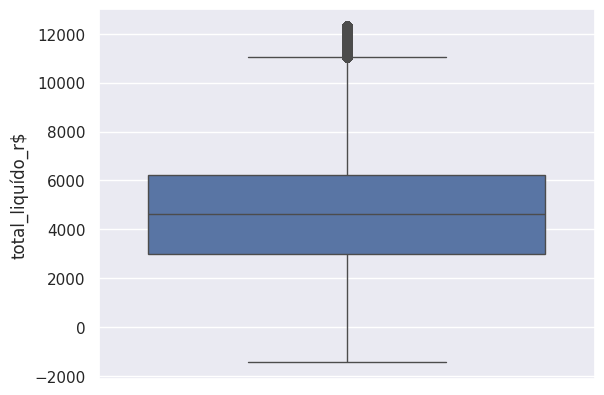

In [ ]:
sns.boxplot(cleaned_df['total_liquído_r$'])

In [ ]:
cleaned_df.to_csv('dataset_limpo_se.csv', index=False)

<Axes: >

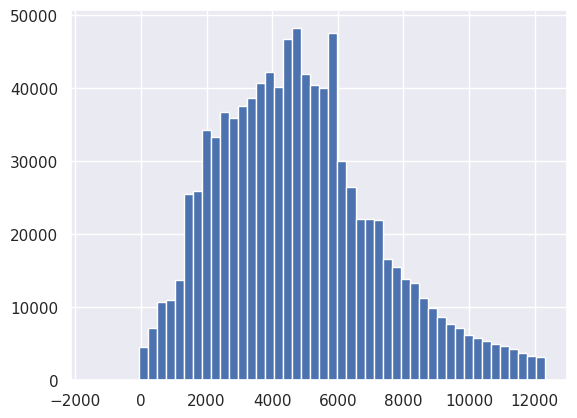

In [ ]:
cleaned_df['total_liquído_r$'].hist(bins=50)

Bem diferente não?

# **6.2. Abordagem utilizando desvio padrão**

Explicação:
- Calcular Média e Desvio Padrão: A função remove_above_std_for_column calcula a média (mean) e o desvio padrão (std_dev) da coluna especificada.
- Definir Limite Superior: O limite superior é calculado para identificar valores que estão significativamente acima da média. Você pode ajustar esse fator se necessário.
- Definir Limite Inferior: O limite inferior é calculado para identificar valores que estão significativamente abaixo da média. Você pode ajustar esse fator se necessário.
- Filtrar o DataFrame: Filtra o DataFrame para salvar o extremos.
- Depois limpamos o dataset para remover os extremos.

**6.2 Abordagem utilizando desvio padrão - para outliers superiores a 3 desvio padrão.**

In [ ]:
def filter_above_iqr_for_column(df, column_name):
    # Calcular média e desvio padrão
    mean = df[column_name].mean()
    std_dev = df[column_name].std()

    # Limite inferior
    upper_bound = mean + 3 * std_dev

    # Filtrar valores acima do limite superior
    column_outliers = df[df[column_name] > upper_bound]

    return column_outliers

# Filtrar valores superiores ao IQR para a coluna 'XXXX'
outliers_up = filter_above_iqr_for_column(df, 'total_liquído_r$')

# Exibir os resultados
print("Valores superiores ao IQR na coluna 'total_liquído_r$':")
print(outliers_up)

Valores superiores ao IQR na coluna 'total_liquído_r$':
                                   nome  \
47             ABBOUD ZAKI BADR TANNOUS   
59                       ABDALA HEDJAZI   
82               ABDIAS MOTTA GONCALVES   
140         ABEL BATISTA CAMILLO JUNIOR   
184          ABEL FERNANDES BARRIONUEVO   
...                                 ...   
1039362      ZULEIKA RAMOS DE O SANCHES   
1039411         ZULENE CAVALCANTE GOMES   
1039461      ZULMARA DE FATIMA MODENESI   
1039574      ZULMIRA GUIMARAES BERTUCCI   
1039635  ZULMIRA RODRIGUES DA COSTA CAM   

                                           cargo  \
47                AUDITOR FISCAL DA RECEITA ESTA   
59                AUDITOR FISCAL DA RECEITA ESTA   
82                                      1SGT  PM   
140                                       CEL PM   
184               AUDITOR FISCAL DA RECEITA ESTA   
...                                          ...   
1039362  BENEFICIARIO DE SERVIDOR ESTADUAL-IPESP   
1039411   B

**6.2 Abordagem utilizando desvio padrão - para outliers inferiores a 3 desvio padrão.**

In [ ]:
def filter_below_std_for_column(df, column_name):
    # Calcular média e desvio padrão
    mean = df[column_name].mean()
    std_dev = df[column_name].std()

    # Limite inferior
    lower_bound = mean - 3 * std_dev

    # Filtrar valores abaixo do limite inferior
    column_outliers = df[df[column_name] < lower_bound]

    return column_outliers

# Filtrar valores abaixo do desvio padrão para a coluna 'MSRP'
outliers = filter_below_std_for_column(df, 'total_liquído_r$')

# Exibir os resultados
print("Valores abaixo do desvio padrão na coluna 'total_liquído_r$':")
print(outliers)

Valores abaixo do desvio padrão na coluna 'total_liquído_r$':
                                nome                         cargo  \
53149   ANA LIDIA DE OLIVEIRA AGUIAR  PROFESSOR EDUCACAO BASICA II   
169483    CLAUDEMIR ALVES DOS SANTOS  TEC.DESENV.ORGANIZ. - FUNDAP   
455282           JORGE TATINO JUNIOR      CCESP 1.17-SUBSECRETARIO   
908391     SEBASTIAO ROBERTO CARRARA  PROFESSOR EDUCACAO BASICA II   

                                 orgão  remuneração_do_mês  \
53149           SECRETARIA DA EDUCACAO                0.00   
169483  SECRETARIA GESTAO GOVERNO DIG.                0.00   
455282  SECR.DESENVOLVIMENTO ECONOMICO            23728.00   
908391          SECRETARIA DA EDUCACAO              427.27   

        férias_e_13º_salário  pagamentos_eventuais  licença_prêmio_indenizada  \
53149                   0.00             -20943.77                        0.0   
169483               4501.33             -16439.63                        0.0   
455282                  0.00     

**6.2. Removendo outliers utilizando o Desvio Padrão**

Uma abordagem simples é considerar dados que estão a mais de 2 ou 3 desvios padrões da média como outliers.

**Removendo Ouliers maiores do que 3 desvio padrão**

In [ ]:
def remove_above_std_for_column(df, column_name):
    # Calcular média e desvio padrão
    mean = df[column_name].mean()
    std_dev = df[column_name].std()

    # Limite superior
    upper_bound = mean + 3 * std_dev

    # Filtrar valores abaixo do limite superior
    filtered_df = df[df[column_name] <= upper_bound]

    return filtered_df

# Remover valores acima do desvio padrão para a coluna 'MSRP'
cleaned_df_sd = remove_above_std_for_column(df, 'total_liquído_r$')

# Exibir os resultados
print("DataFrame após remover os valores acima do desvio padrão na coluna 'total_liquído_r$':")
print(cleaned_df_sd)

DataFrame após remover os valores acima do desvio padrão na coluna 'total_liquído_r$':
                                   nome  \
0          A UCENA ROSA REGINALDO SILVA   
1        AA HELENA PEREIRA ISOLDI DOS S   
2                 AALAN DA SILVA ARAUJO   
3            AARAN ESTEVAO LIMA BARBOSA   
4               AARAO HENRIQUE OLIVEIRA   
...                                 ...   
1039701            ZURMA DE SOUZA PINTO   
1039702          ZUVIA OSPEDAL DA SILVA   
1039703          ZUVIA OSPEDAL DA SILVA   
1039704       ZUZIMEIRE TOSTES DA SILVA   
1039705                ZUZU DE OLIVEIRA   

                                           cargo  \
0                                     ESTAGIARIO   
1                   AGENTE DE SERVICOS ESCOLARES   
2                                       SD 1C PM   
3                                       CAP   PM   
4                               POLICIAL PENAL I   
...                                          ...   
1039701            PROF ENSINO F

**Removendo Ouliers menores do que 3 desvio padrão**

In [ ]:
def remove_below_std_for_column(df, column_name):
    # Calcular média e desvio padrão
    mean = df[column_name].mean()
    std_dev = df[column_name].std()

    # Limite inferior
    lower_bound = mean - 3 * std_dev

    # Filtrar valores acima do limite inferior
    filtered_df = df[df[column_name] >= lower_bound]

    return filtered_df

# Remover valores abaixo de 3 desvios padrão para a coluna 'MSRP'
cleaned_df_sd = remove_below_std_for_column(cleaned_df_sd, 'total_liquído_r$')

# Exibir os resultados
print("DataFrame após remover os valores abaixo de 3 desvios padrão na coluna 'total_liquído_r$':")
print(cleaned_df_sd)

DataFrame após remover os valores abaixo de 3 desvios padrão na coluna 'total_liquído_r$':
                                   nome  \
0          A UCENA ROSA REGINALDO SILVA   
1        AA HELENA PEREIRA ISOLDI DOS S   
2                 AALAN DA SILVA ARAUJO   
3            AARAN ESTEVAO LIMA BARBOSA   
4               AARAO HENRIQUE OLIVEIRA   
...                                 ...   
1039701            ZURMA DE SOUZA PINTO   
1039702          ZUVIA OSPEDAL DA SILVA   
1039703          ZUVIA OSPEDAL DA SILVA   
1039704       ZUZIMEIRE TOSTES DA SILVA   
1039705                ZUZU DE OLIVEIRA   

                                           cargo  \
0                                     ESTAGIARIO   
1                   AGENTE DE SERVICOS ESCOLARES   
2                                       SD 1C PM   
3                                       CAP   PM   
4                               POLICIAL PENAL I   
...                                          ...   
1039701            PROF ENSI

**Tarefa:**
- Compare os resutlados da abordagem IQR, desvio padrão e SVM para uma variável, refazendo a análise exploratório após a remoção de outliers.**

<Axes: ylabel='total_liquído_r$'>

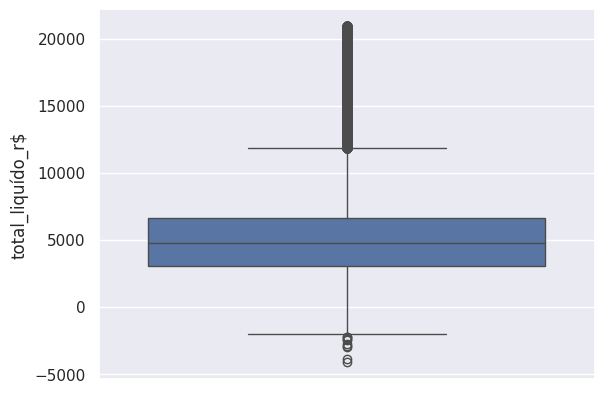

In [ ]:
sns.boxplot(cleaned_df_sd['total_liquído_r$'])

<Axes: >

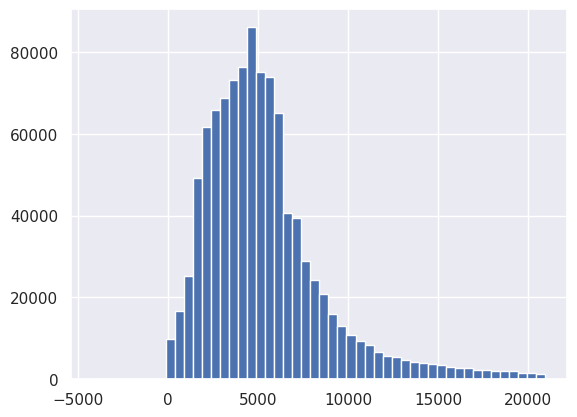

In [ ]:
cleaned_df_sd['total_liquído_r$'].hist(bins=50)

**Resumo**

Escolher o método apropriado depende do contexto e dos requisitos da análise. O método do desvio padrão é simples e rápido, enquanto o IQR é mais robusto e frequentemente usado para dados não normalmente distribuídos.

Os Boxplots são úteis para visualização da distribuição de valores em relação a extremos e histogramas permite verificar como ocorre a distribuição dos valores em termos de frequência.

O que acha?

Viu como só o uso da EDA já permite conhecer muito sobre o dataset?

Acha que após a análise você tomaria decisões diferentes de como trabalhar esses dados?

Na aula que vem amos ver o que acontece a partir disso.